In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split , KFold , cross_val_score ,GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn import metrics
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

<p style="font-size:16px">Libraries are imported.<br>
then csv files must be changed to Data frames </p>

In [2]:
data=pd.read_csv("train.csv")
test_data=pd.read_csv("test.csv")

In [3]:
df=pd.DataFrame(data)
test_df=pd.DataFrame(test_data)

In [4]:
test_df.drop("id",axis=1,inplace=True)

In [5]:
test_df

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,pc,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi
0,1043,1,1.8,1,14,0,5,0.1,193,3,16,226,1412,3476,12,7,2,0,1,0
1,841,1,0.5,1,4,1,61,0.8,191,5,12,746,857,3895,6,0,7,1,0,0
2,1807,1,2.8,0,1,0,27,0.9,186,3,4,1270,1366,2396,17,10,10,0,1,1
3,1546,0,0.5,1,18,1,25,0.5,96,8,20,295,1752,3893,10,0,7,1,1,0
4,1434,0,1.4,0,11,1,49,0.5,108,6,18,749,810,1773,15,8,7,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,1700,1,1.9,0,0,1,54,0.5,170,7,17,644,913,2121,14,8,15,1,1,0
996,609,0,1.8,1,0,0,13,0.9,186,4,2,1152,1632,1933,8,1,19,0,1,1
997,1185,0,1.4,0,1,1,8,0.5,80,1,12,477,825,1223,5,0,14,1,0,0
998,1533,1,0.5,1,0,0,50,0.4,171,2,12,38,832,2509,15,11,6,0,1,0


In [6]:
df

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,...,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,...,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,...,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,...,1208,1212,1411,8,2,15,1,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,794,1,0.5,1,0,1,2,0.8,106,6,...,1222,1890,668,13,4,19,1,1,0,0
1996,1965,1,2.6,1,0,0,39,0.2,187,4,...,915,1965,2032,11,10,16,1,1,1,2
1997,1911,0,0.9,1,1,1,36,0.7,108,8,...,868,1632,3057,9,1,5,1,1,0,3
1998,1512,0,0.9,0,4,1,46,0.1,145,5,...,336,670,869,18,10,19,1,1,1,0


<span style="font-size:16px">Both train and test datas must be visually checked to make shure numbers features<span style="color:red">(x)</span> are in  a same range so model can train with same range of inputs and be tested on same range of outputs. </span>

In [7]:
df.describe(include="all")

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
count,2000.000000,2000.0000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,...,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,1238.518500,0.4950,1.522250,0.509500,4.309500,0.521500,32.046500,0.501750,140.249000,4.520500,...,645.108000,1251.515500,2124.213000,12.306500,5.767000,11.011000,0.761500,0.503000,0.507000,1.500000
std,439.418206,0.5001,0.816004,0.500035,4.341444,0.499662,18.145715,0.288416,35.399655,2.287837,...,443.780811,432.199447,1084.732044,4.213245,4.356398,5.463955,0.426273,0.500116,0.500076,1.118314
min,501.000000,0.0000,0.500000,0.000000,0.000000,0.000000,2.000000,0.100000,80.000000,1.000000,...,0.000000,500.000000,256.000000,5.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000
25%,851.750000,0.0000,0.700000,0.000000,1.000000,0.000000,16.000000,0.200000,109.000000,3.000000,...,282.750000,874.750000,1207.500000,9.000000,2.000000,6.000000,1.000000,0.000000,0.000000,0.750000
50%,1226.000000,0.0000,1.500000,1.000000,3.000000,1.000000,32.000000,0.500000,141.000000,4.000000,...,564.000000,1247.000000,2146.500000,12.000000,5.000000,11.000000,1.000000,1.000000,1.000000,1.500000
75%,1615.250000,1.0000,2.200000,1.000000,7.000000,1.000000,48.000000,0.800000,170.000000,7.000000,...,947.250000,1633.000000,3064.500000,16.000000,9.000000,16.000000,1.000000,1.000000,1.000000,2.250000
max,1998.000000,1.0000,3.000000,1.000000,19.000000,1.000000,64.000000,1.000000,200.000000,8.000000,...,1960.000000,1998.000000,3998.000000,19.000000,18.000000,20.000000,1.000000,1.000000,1.000000,3.000000


In [8]:
test_df.describe(include="all")

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,pc,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000
mean,1248.510000,0.516000,1.540900,0.517000,4.593000,0.487000,33.652000,0.517500,139.51100,4.328000,10.054000,627.121000,1239.774000,2138.998000,11.995000,5.316000,11.085000,0.756000,0.50000,0.507000
std,432.458227,0.499994,0.829268,0.499961,4.463325,0.500081,18.128694,0.280861,34.85155,2.288155,6.095099,432.929699,439.670981,1088.092278,4.320607,4.240062,5.497636,0.429708,0.50025,0.500201
min,500.000000,0.000000,0.500000,0.000000,0.000000,0.000000,2.000000,0.100000,80.00000,1.000000,0.000000,0.000000,501.000000,263.000000,5.000000,0.000000,2.000000,0.000000,0.00000,0.000000
25%,895.000000,0.000000,0.700000,0.000000,1.000000,0.000000,18.000000,0.300000,109.75000,2.000000,5.000000,263.750000,831.750000,1237.250000,8.000000,2.000000,6.750000,1.000000,0.00000,0.000000
50%,1246.500000,1.000000,1.500000,1.000000,3.000000,0.000000,34.500000,0.500000,139.00000,4.000000,10.000000,564.500000,1250.000000,2153.500000,12.000000,5.000000,11.000000,1.000000,0.50000,1.000000
75%,1629.250000,1.000000,2.300000,1.000000,7.000000,1.000000,49.000000,0.800000,170.00000,6.000000,16.000000,903.000000,1637.750000,3065.500000,16.000000,8.000000,16.000000,1.000000,1.00000,1.000000
max,1999.000000,1.000000,3.000000,1.000000,19.000000,1.000000,64.000000,1.000000,200.00000,8.000000,20.000000,1907.000000,1998.000000,3989.000000,19.000000,18.000000,20.000000,1.000000,1.00000,1.000000


In [9]:
df.isna().sum()

battery_power    0
blue             0
clock_speed      0
dual_sim         0
fc               0
four_g           0
int_memory       0
m_dep            0
mobile_wt        0
n_cores          0
pc               0
px_height        0
px_width         0
ram              0
sc_h             0
sc_w             0
talk_time        0
three_g          0
touch_screen     0
wifi             0
price_range      0
dtype: int64

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   battery_power  2000 non-null   int64  
 1   blue           2000 non-null   int64  
 2   clock_speed    2000 non-null   float64
 3   dual_sim       2000 non-null   int64  
 4   fc             2000 non-null   int64  
 5   four_g         2000 non-null   int64  
 6   int_memory     2000 non-null   int64  
 7   m_dep          2000 non-null   float64
 8   mobile_wt      2000 non-null   int64  
 9   n_cores        2000 non-null   int64  
 10  pc             2000 non-null   int64  
 11  px_height      2000 non-null   int64  
 12  px_width       2000 non-null   int64  
 13  ram            2000 non-null   int64  
 14  sc_h           2000 non-null   int64  
 15  sc_w           2000 non-null   int64  
 16  talk_time      2000 non-null   int64  
 17  three_g        2000 non-null   int64  
 18  touch_sc

In [11]:
df.duplicated().sum()

np.int64(0)

<h3>Data Details</h3>
<span style="font-size:16px"><b>battery_power</b>:Total energy a batter can store in one time measured in mAh<br>
<b>blue</b>:Has bluetooth or not<br> 
<b>clock_speed</b>:speed at wich microprocessor execute instructions<br>
<b>dual_sim</b>:Has dual sim support or not<br>
<b>fc</b>:Front camera mega pixel<br>
<b>four_g</b>: Has 4G or not<br>
<b>int_memory</b>:Internal memory in Gigabytes<br>
<b>m_dep</b>:Mobile depth in Cm<br>
<b>mobile_wt</b>:Device weight<br>
<b>n_cores</b>:Number of cores of processor<br>
<b>pc</b>:Primary camera mega pixel<br>
<b>px_height</b>:Pixel resolution Height<br>
<b>px_width</b>:Pixel resolution Width<br>
<b>ram</b>:Random access Memory in mega bytes<br>
<b>sc_h</b>:Screen Height of mobile in cm<br>
<b>sc_w</b>:Screen Width of mobile in cm<br>
<b>talk_time</b>:Longest time that a single battery charge last  when your talking<br>
<b>three_g</b>:Has 3G or not<br>
<b>touch_screen</b>:Has touch screen or not<br>
<b>wifi</b>:Has wifi or not<br>
<b>price_range</b>:This is the target variable with value of 0(low cost),1(medium cost),2(high cost),3(very high cost)<br></span>

<span style="font-size:16px">This plot show us that we have a well balanced data here .All the out comes are relatively the same.</span>

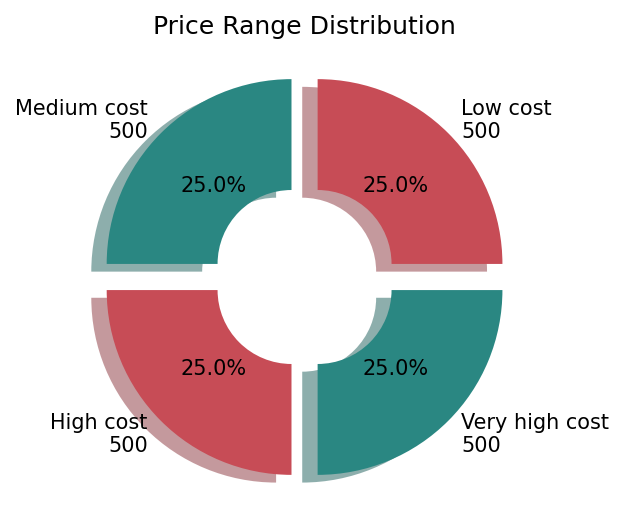

In [12]:
plt.style.use("default")
plt.figure(figsize=(4,4),dpi=150)
count=df["price_range"].value_counts()
lable=[f"Low cost\n{count[0]}",f"Medium cost\n{count[1]}",f"High cost\n{count[2]}" ,f"Very high cost\n{count[3]}"]
explode=(0.1, 0.1,0.1,0.1)
plt.pie(count,explode=explode,labels=lable,autopct='%1.1f%%',
        shadow={'ox': -0.04, 'edgecolor': 'none', 'shade': 0.3},colors=["#c74c56","#2a8782"],wedgeprops=dict(width=0.6))
plt.title("Price Range Distribution")
plt.show()

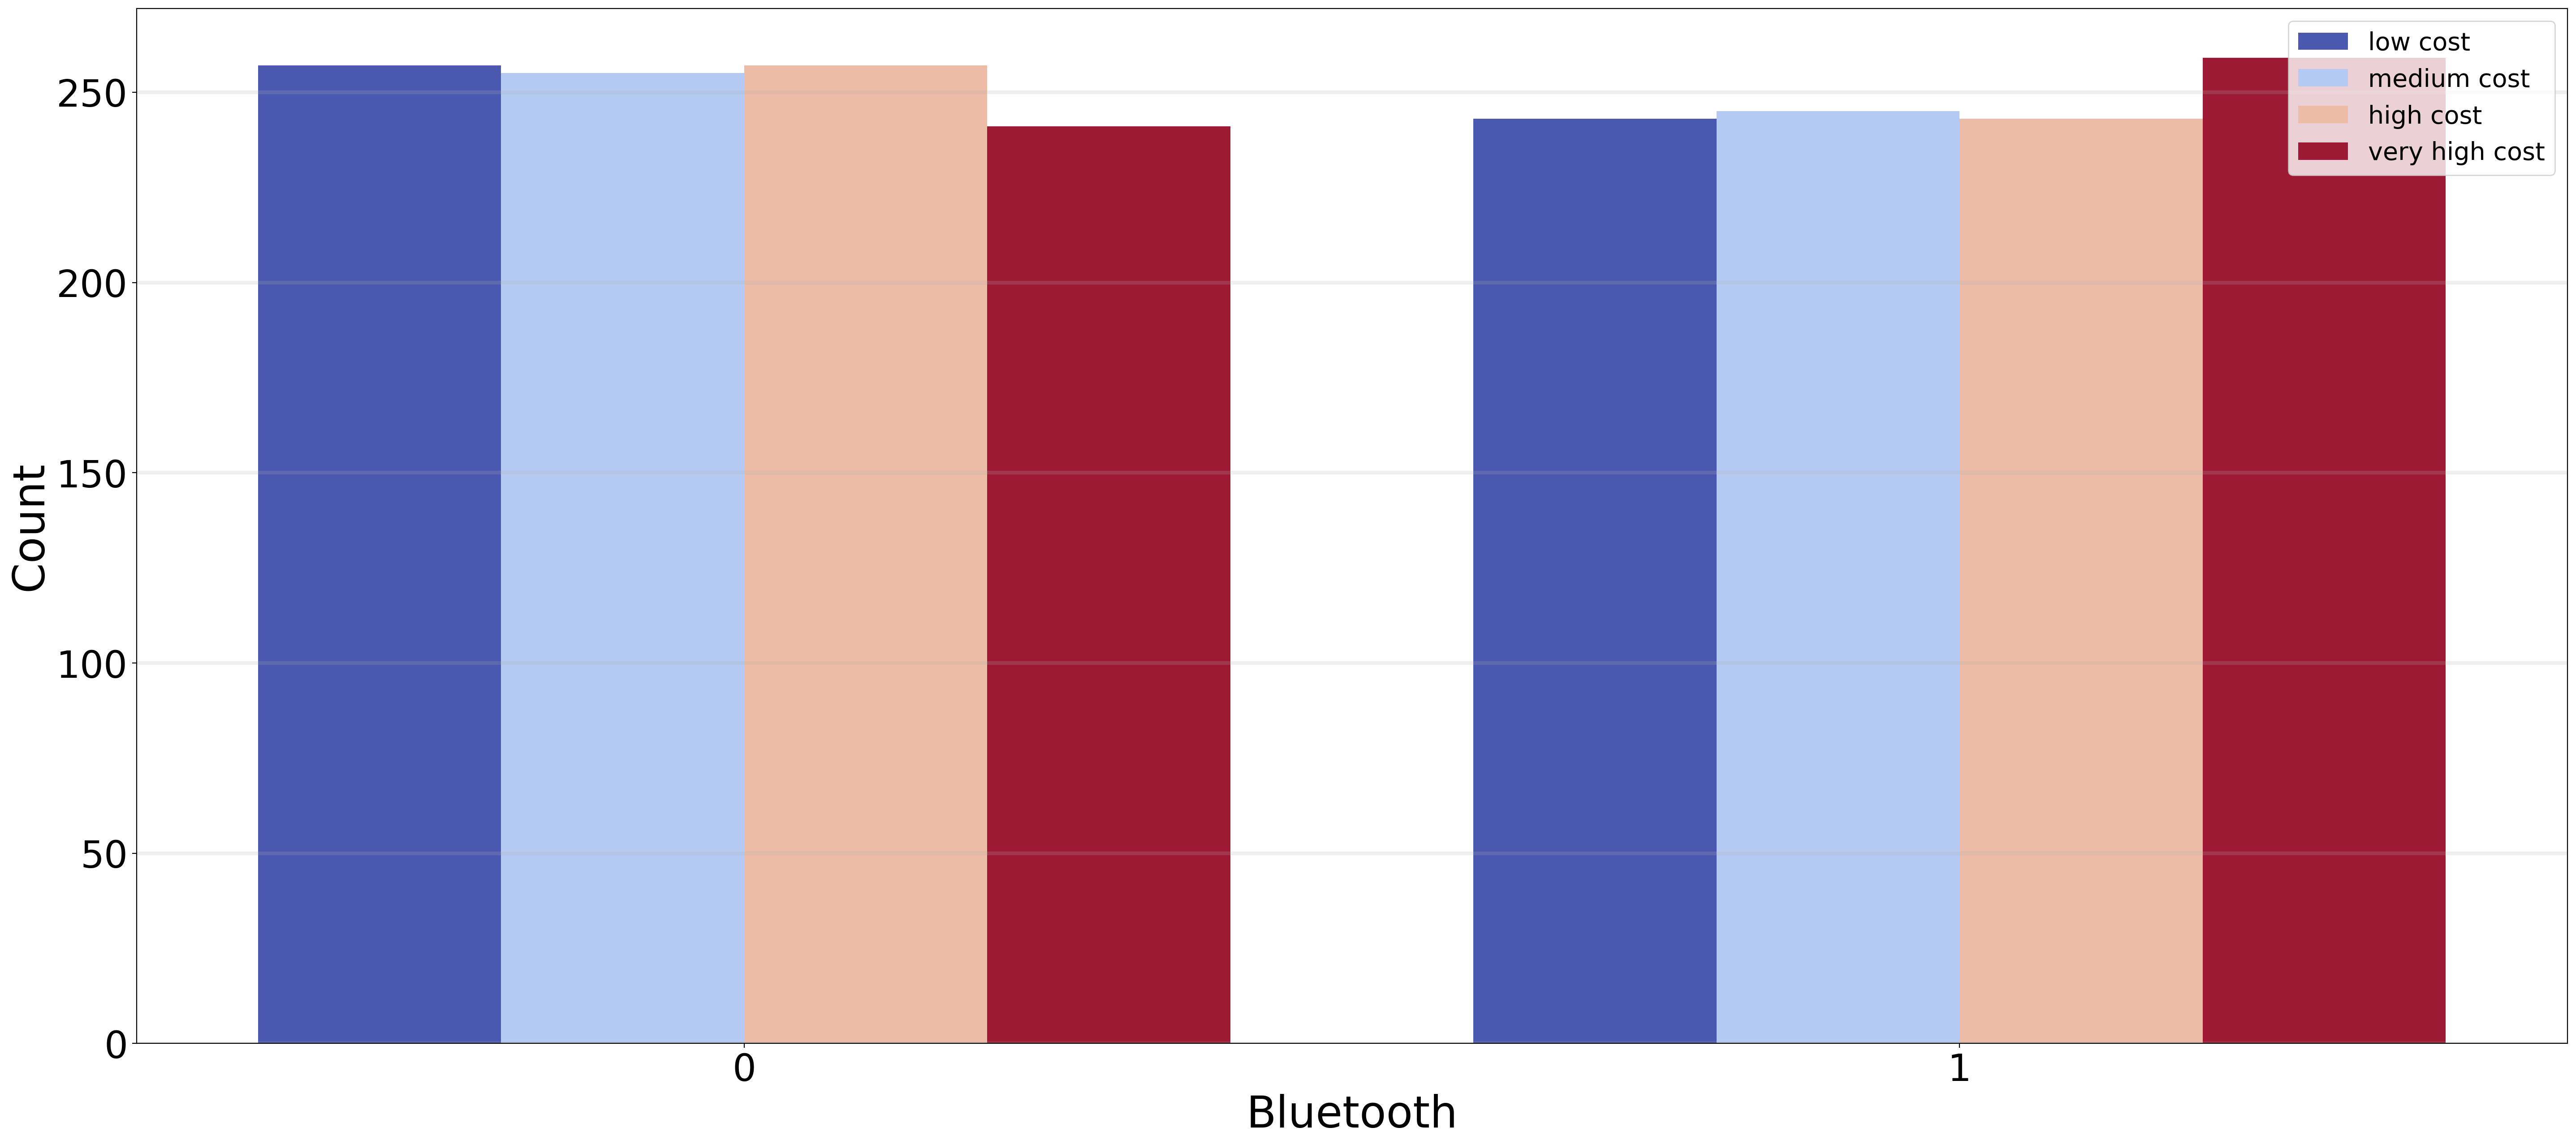

In [13]:
plt.figure(figsize=(35,15),dpi=200)
sns.countplot(data=df, x="blue", hue="price_range",stat="count",palette="coolwarm")
plt.xlabel("Bluetooth",fontsize=35)
plt.ylabel("Count",fontsize=35)
plt.yticks(fontsize=30)
plt.xticks(fontsize=30)
plt.grid(linewidth=3,alpha=0.2,axis="y")
plt.legend(labels=["low cost","medium cost","high cost","very high cost"],loc="upper right",fontsize=20,title_fontsize=22,markerscale=3.5)
plt.show()

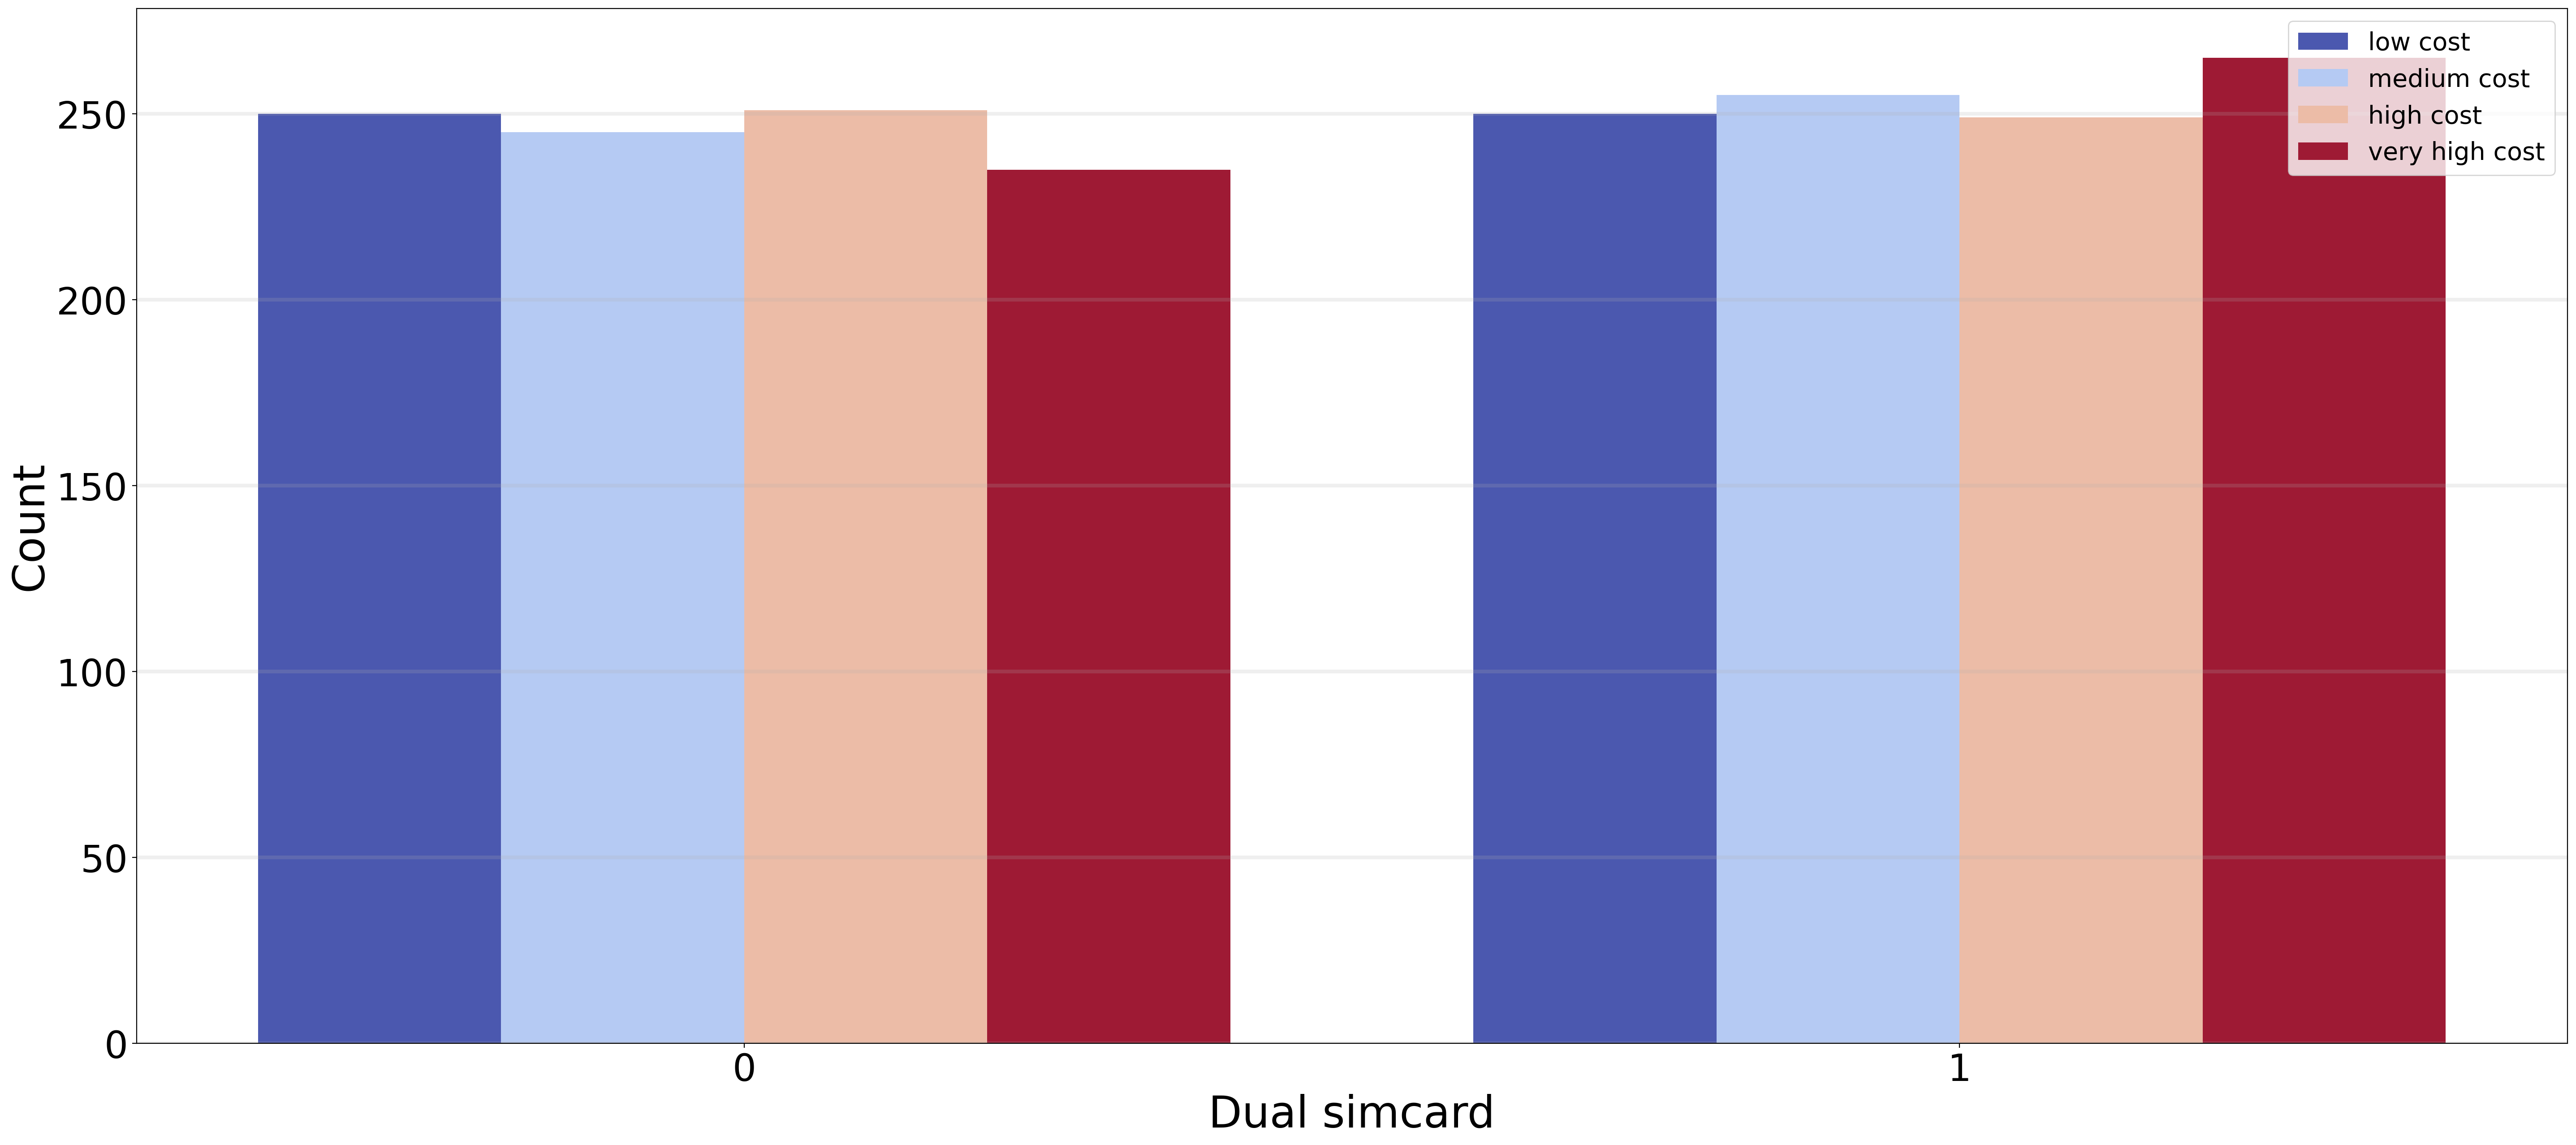

In [14]:
plt.figure(figsize=(35,15),dpi=200)
sns.countplot(data=df, x="dual_sim", hue="price_range",stat="count",palette="coolwarm")
plt.xlabel("Dual simcard",fontsize=35)
plt.ylabel("Count",fontsize=35)
plt.yticks(fontsize=30)
plt.xticks(fontsize=30)
plt.grid(linewidth=3,alpha=0.2,axis="y")
plt.legend(labels=["low cost","medium cost","high cost","very high cost"],loc="upper right",fontsize=20,title_fontsize=22,markerscale=3.5)
plt.show()

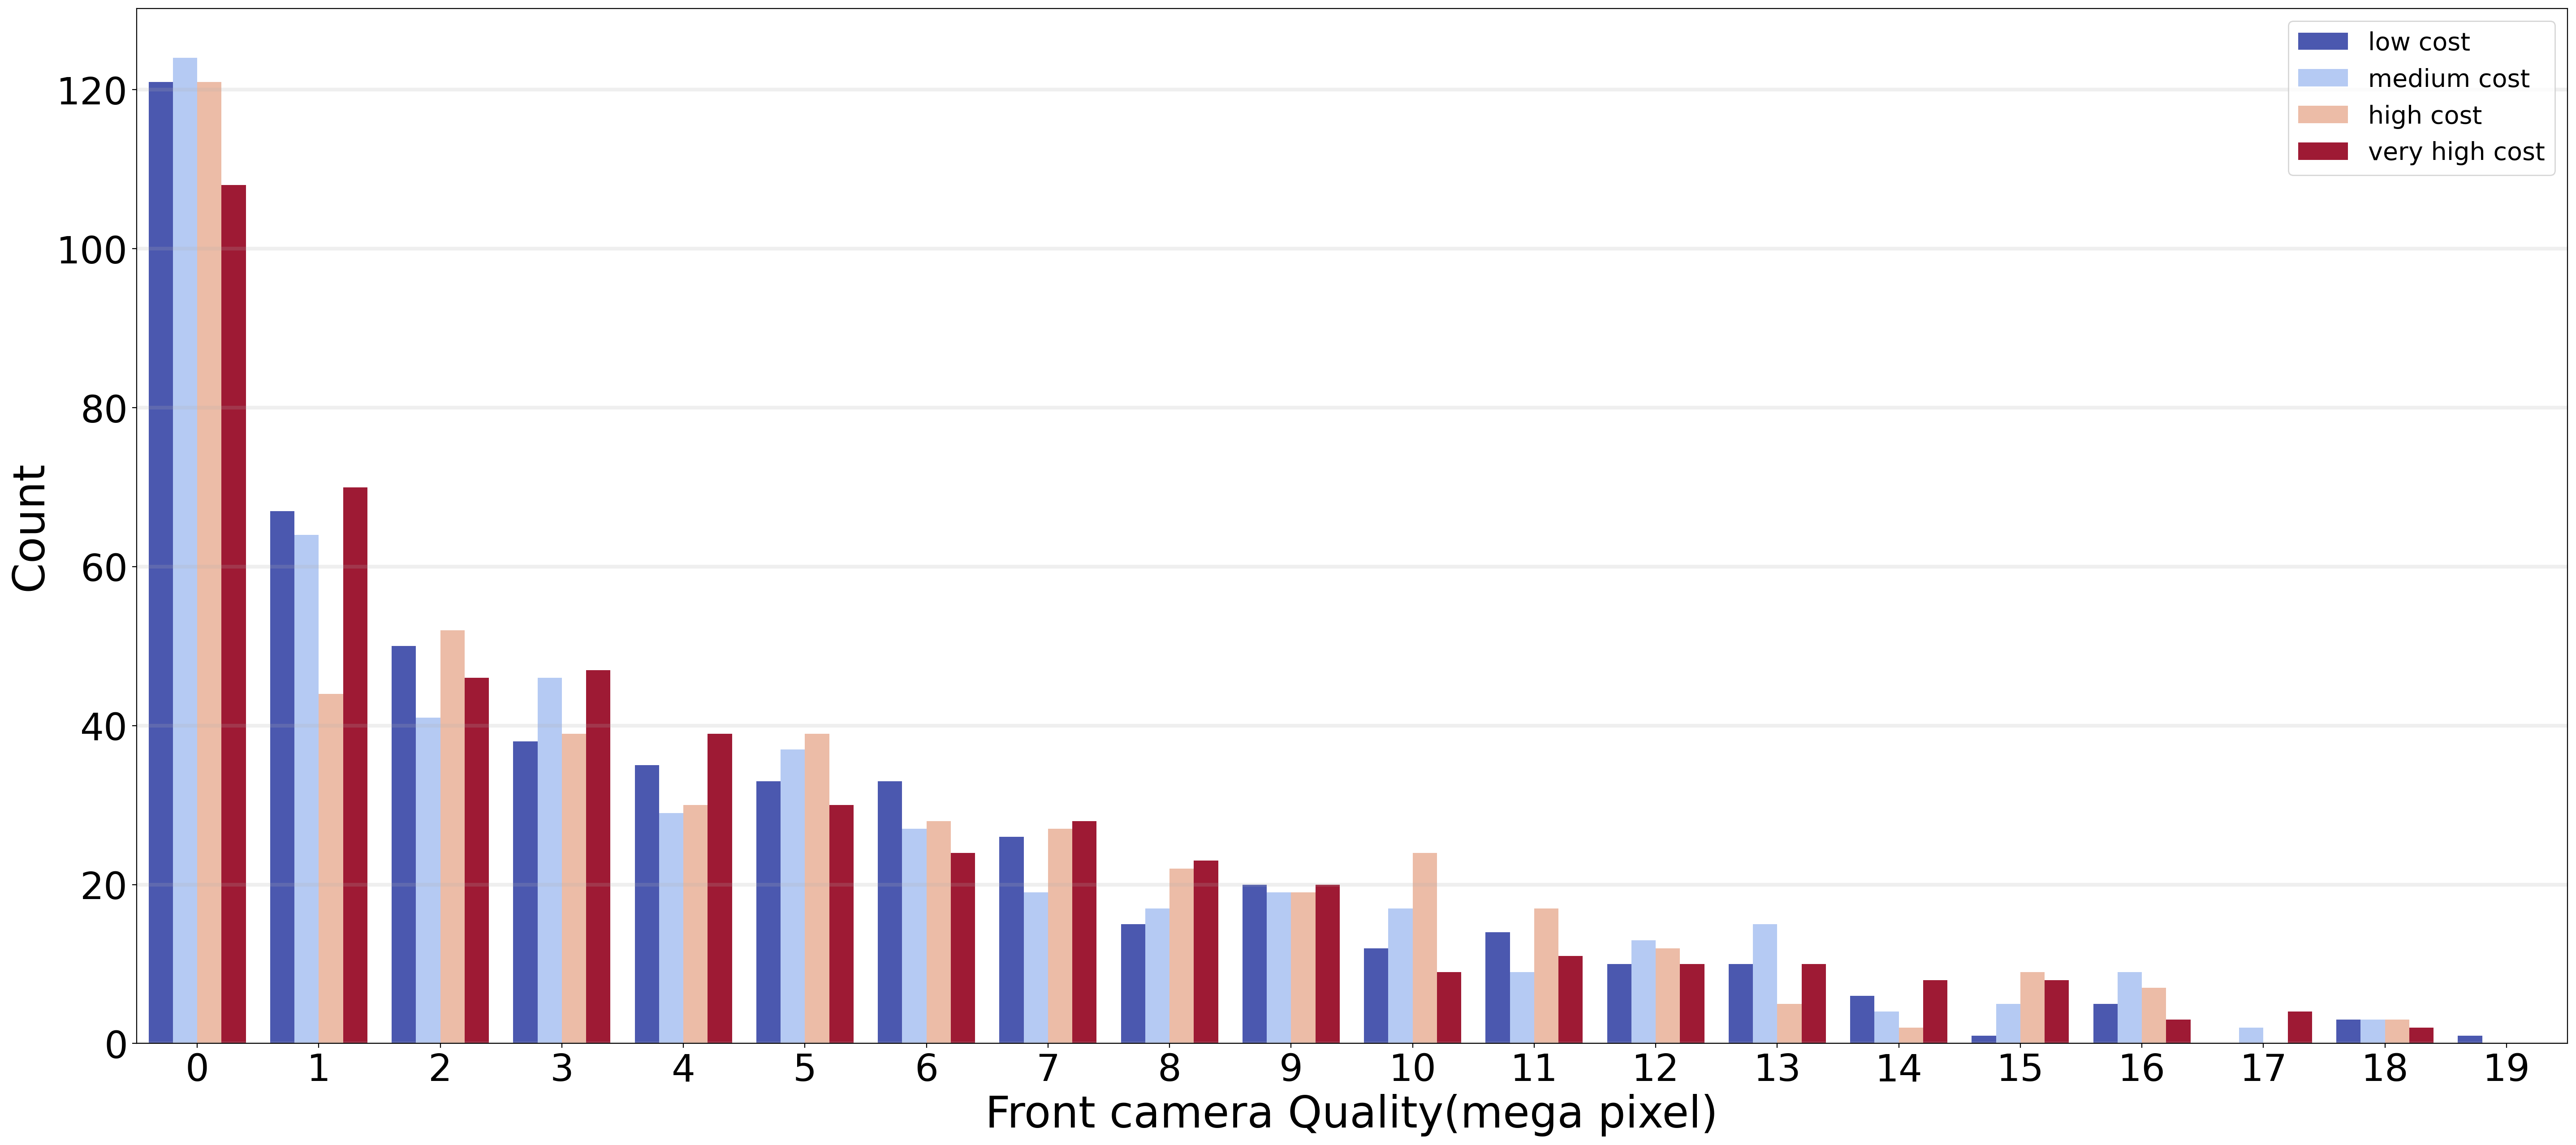

In [15]:
plt.figure(figsize=(35,15),dpi=200)
sns.countplot(data=df, x="fc", hue="price_range",stat="count",palette="coolwarm")
plt.xlabel("Front camera Quality(mega pixel)",fontsize=35)
plt.ylabel("Count",fontsize=35)
plt.yticks(fontsize=30)
plt.xticks(fontsize=30)
plt.grid(linewidth=3,alpha=0.2,axis="y")
plt.legend(labels=["low cost","medium cost","high cost","very high cost"],loc="upper right",fontsize=20,title_fontsize=22,markerscale=3.5)
plt.show()

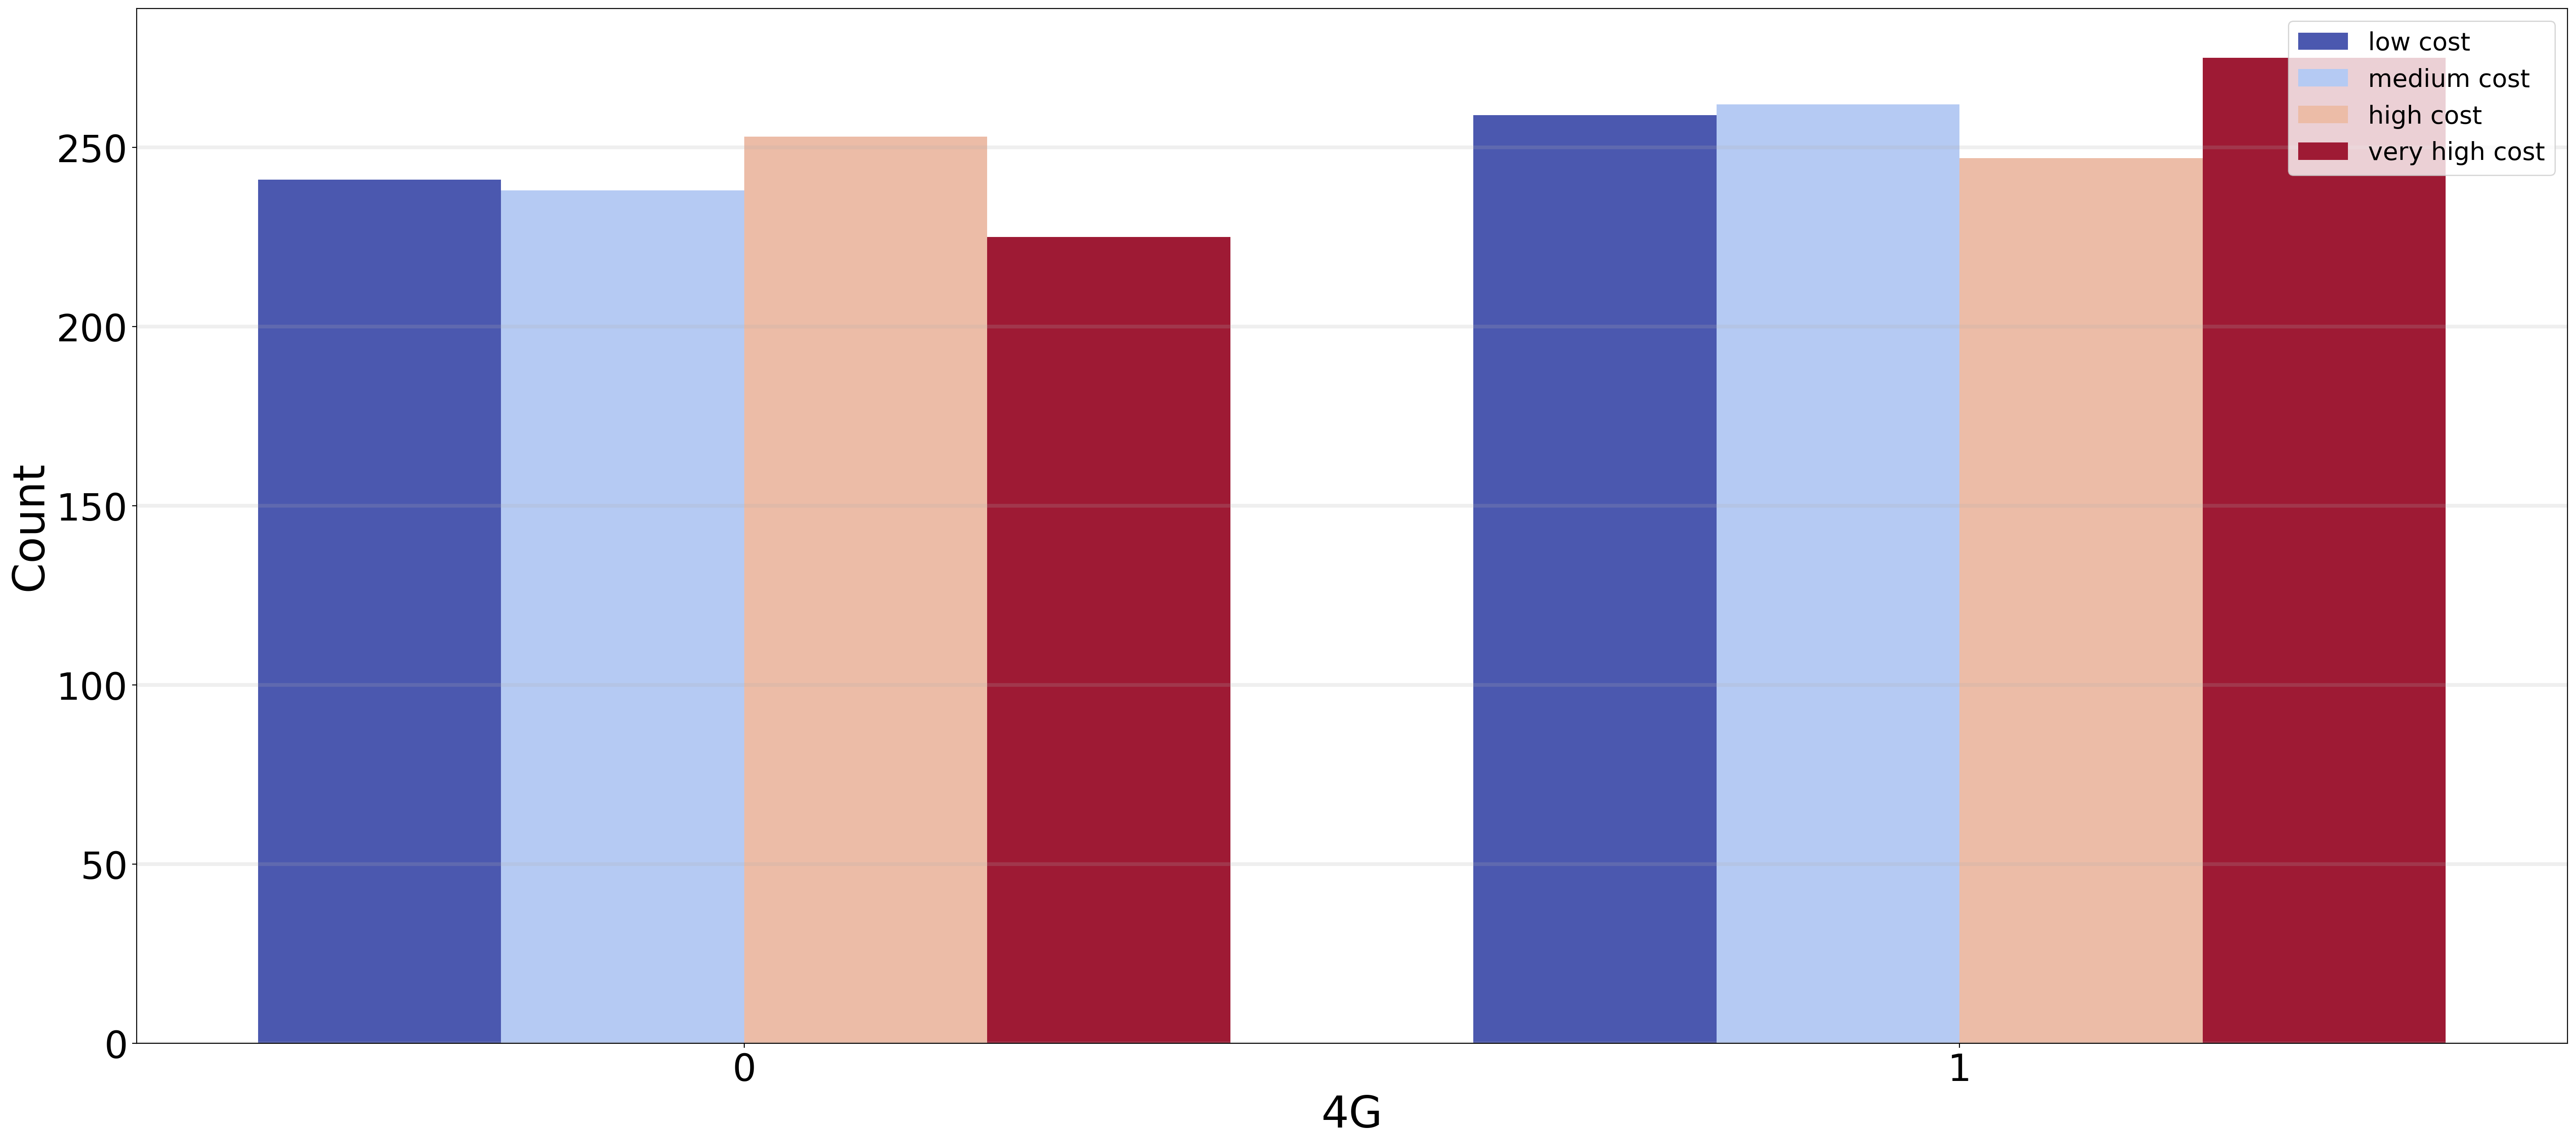

In [16]:
plt.figure(figsize=(35,15),dpi=200)
sns.countplot(data=df, x="four_g", hue="price_range",stat="count",palette="coolwarm")
plt.xlabel("4G",fontsize=35)
plt.ylabel("Count",fontsize=35)
plt.yticks(fontsize=30)
plt.xticks(fontsize=30)
plt.grid(linewidth=3,alpha=0.2,axis="y")
plt.legend(labels=["low cost","medium cost","high cost","very high cost"],loc="upper right",fontsize=20,title_fontsize=22,markerscale=3.5)
plt.show()

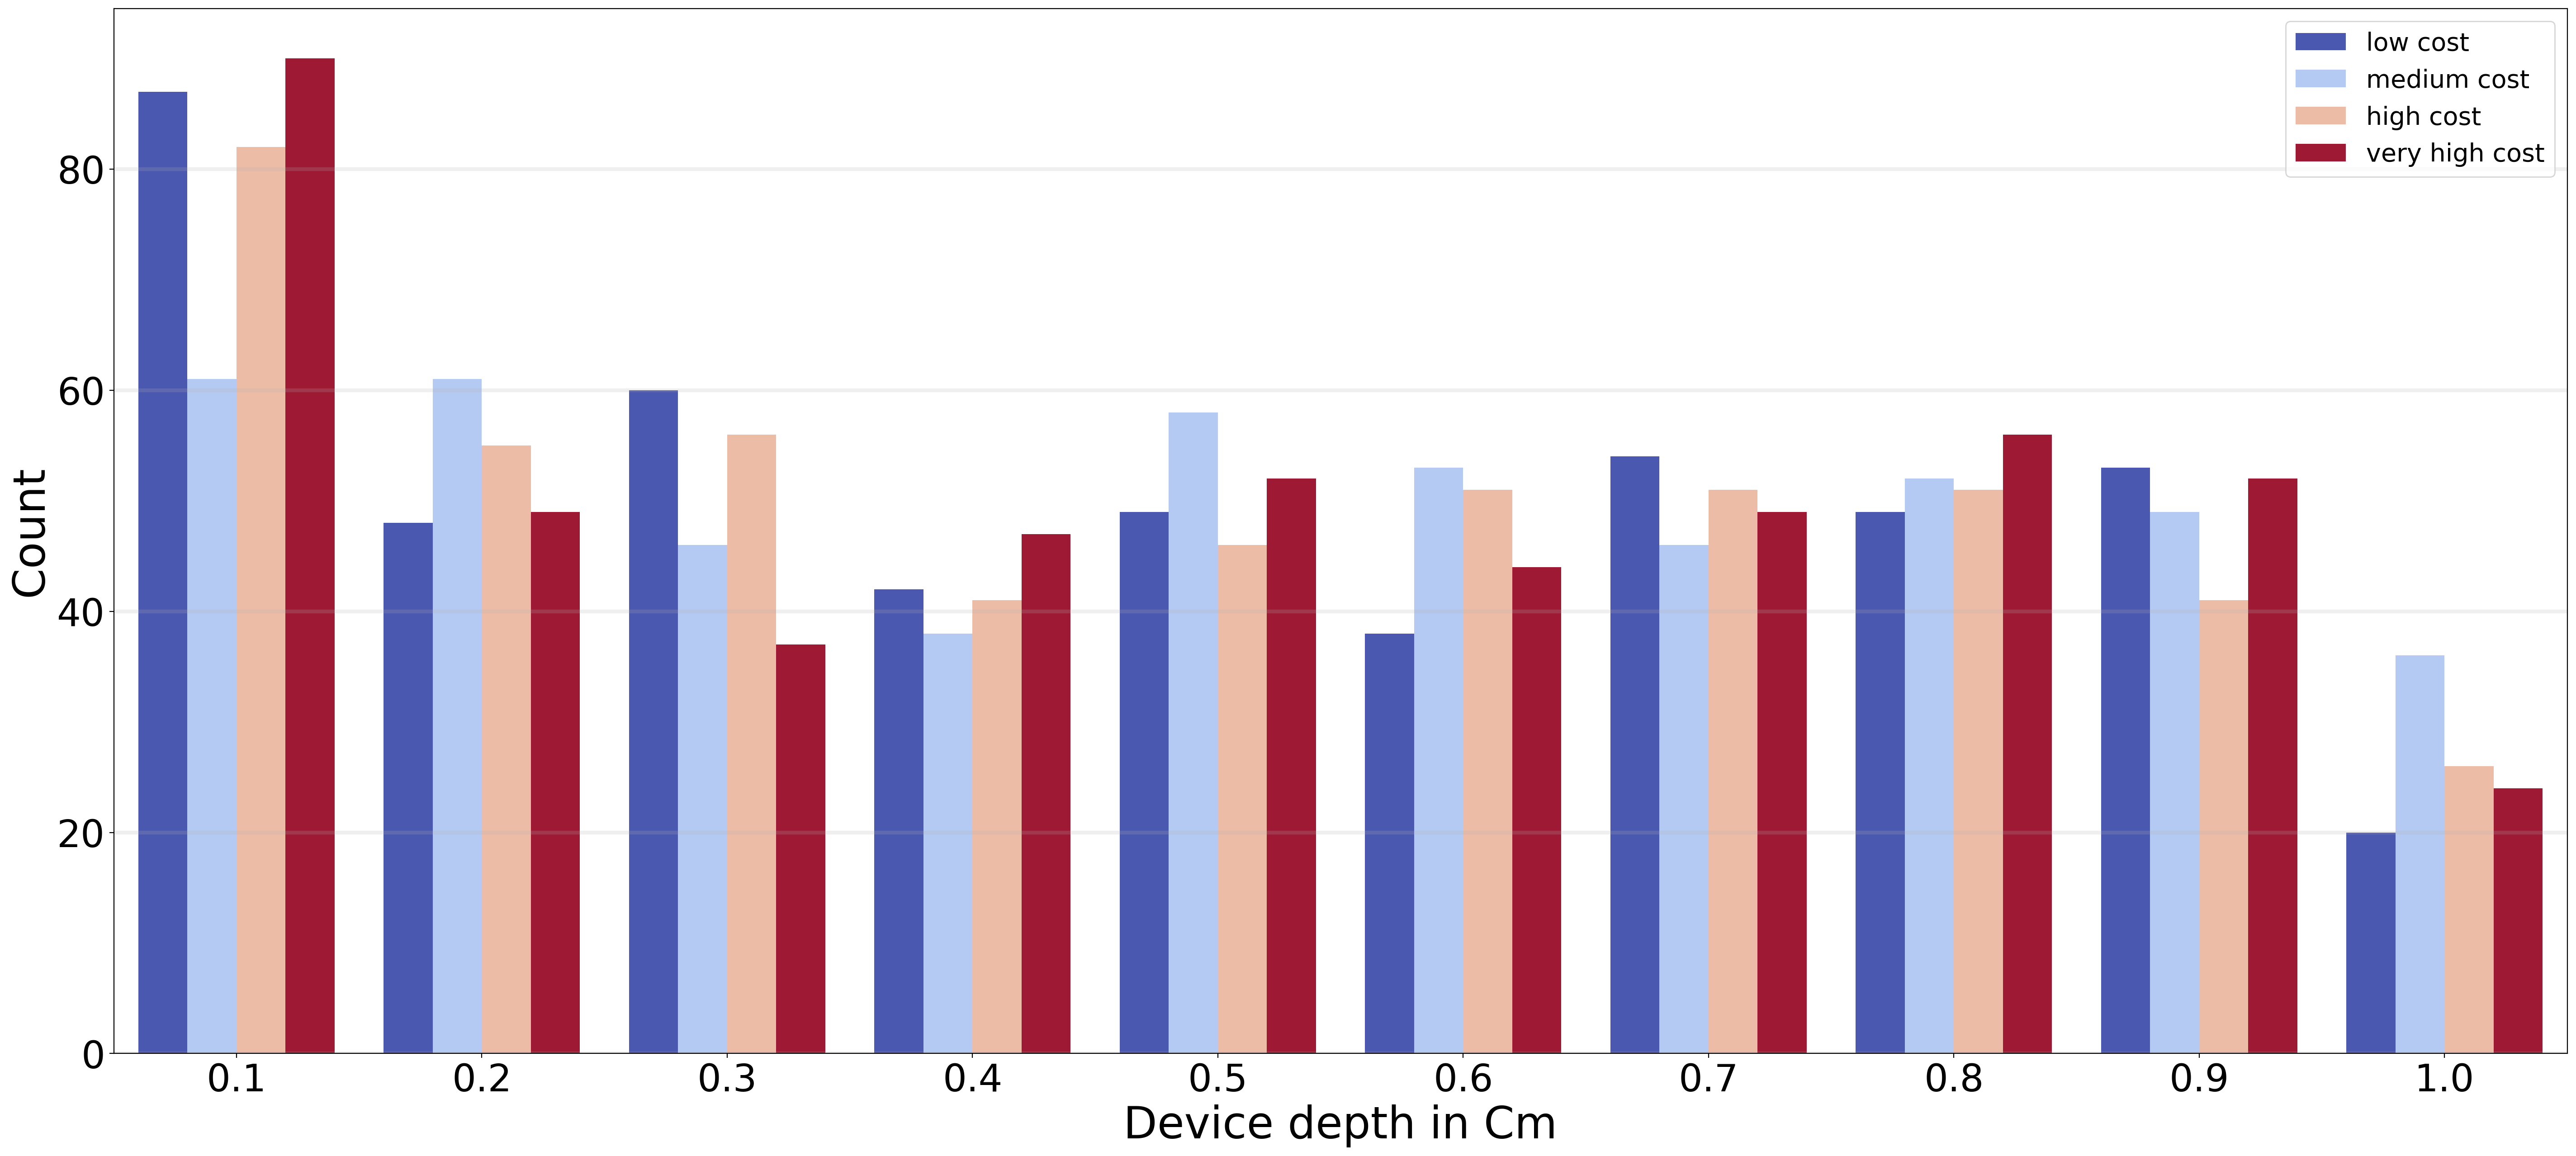

In [17]:
plt.figure(figsize=(35,15),dpi=200)
sns.countplot(data=df, x="m_dep", hue="price_range",stat="count",palette="coolwarm")
plt.xlabel("Device depth in Cm",fontsize=35)
plt.ylabel("Count",fontsize=35)
plt.yticks(fontsize=30)
plt.xticks(fontsize=30)
plt.grid(linewidth=3,alpha=0.2,axis="y")
plt.legend(labels=["low cost","medium cost","high cost","very high cost"],loc="upper right",fontsize=20,title_fontsize=22,markerscale=3.5)
plt.show()

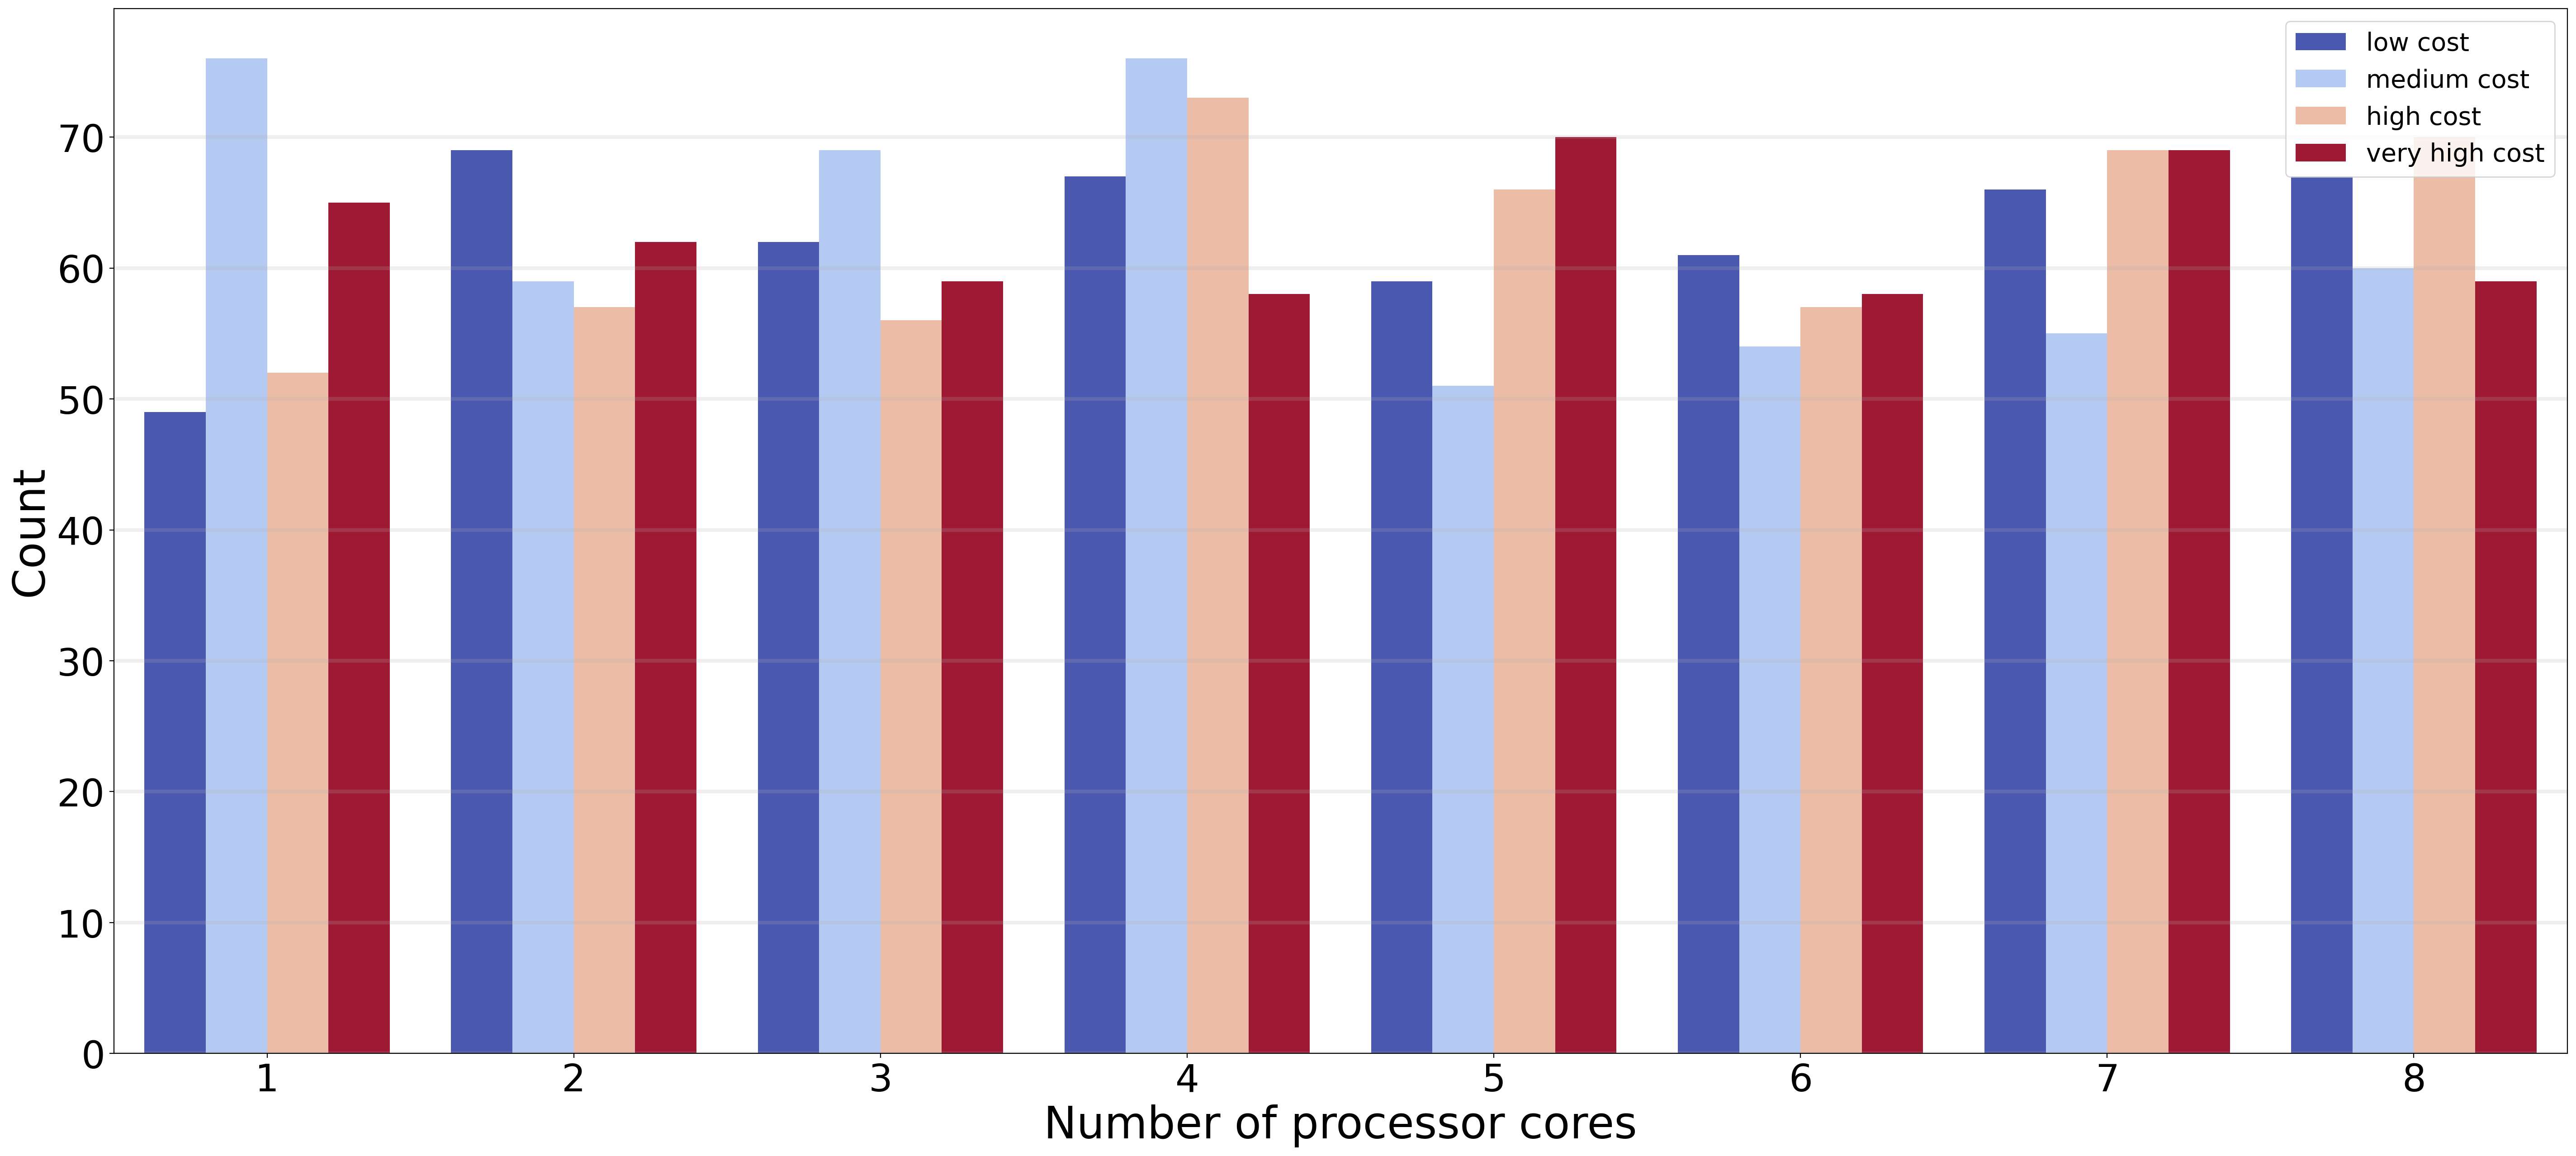

In [18]:
plt.figure(figsize=(35,15),dpi=200)
sns.countplot(data=df, x="n_cores", hue="price_range",stat="count",palette="coolwarm")
plt.xlabel("Number of processor cores",fontsize=35)
plt.ylabel("Count",fontsize=35)
plt.yticks(fontsize=30)
plt.xticks(fontsize=30)
plt.grid(linewidth=3,alpha=0.2,axis="y")
plt.legend(labels=["low cost","medium cost","high cost","very high cost"],loc="upper right",fontsize=20,title_fontsize=22,markerscale=3.5)
plt.show()

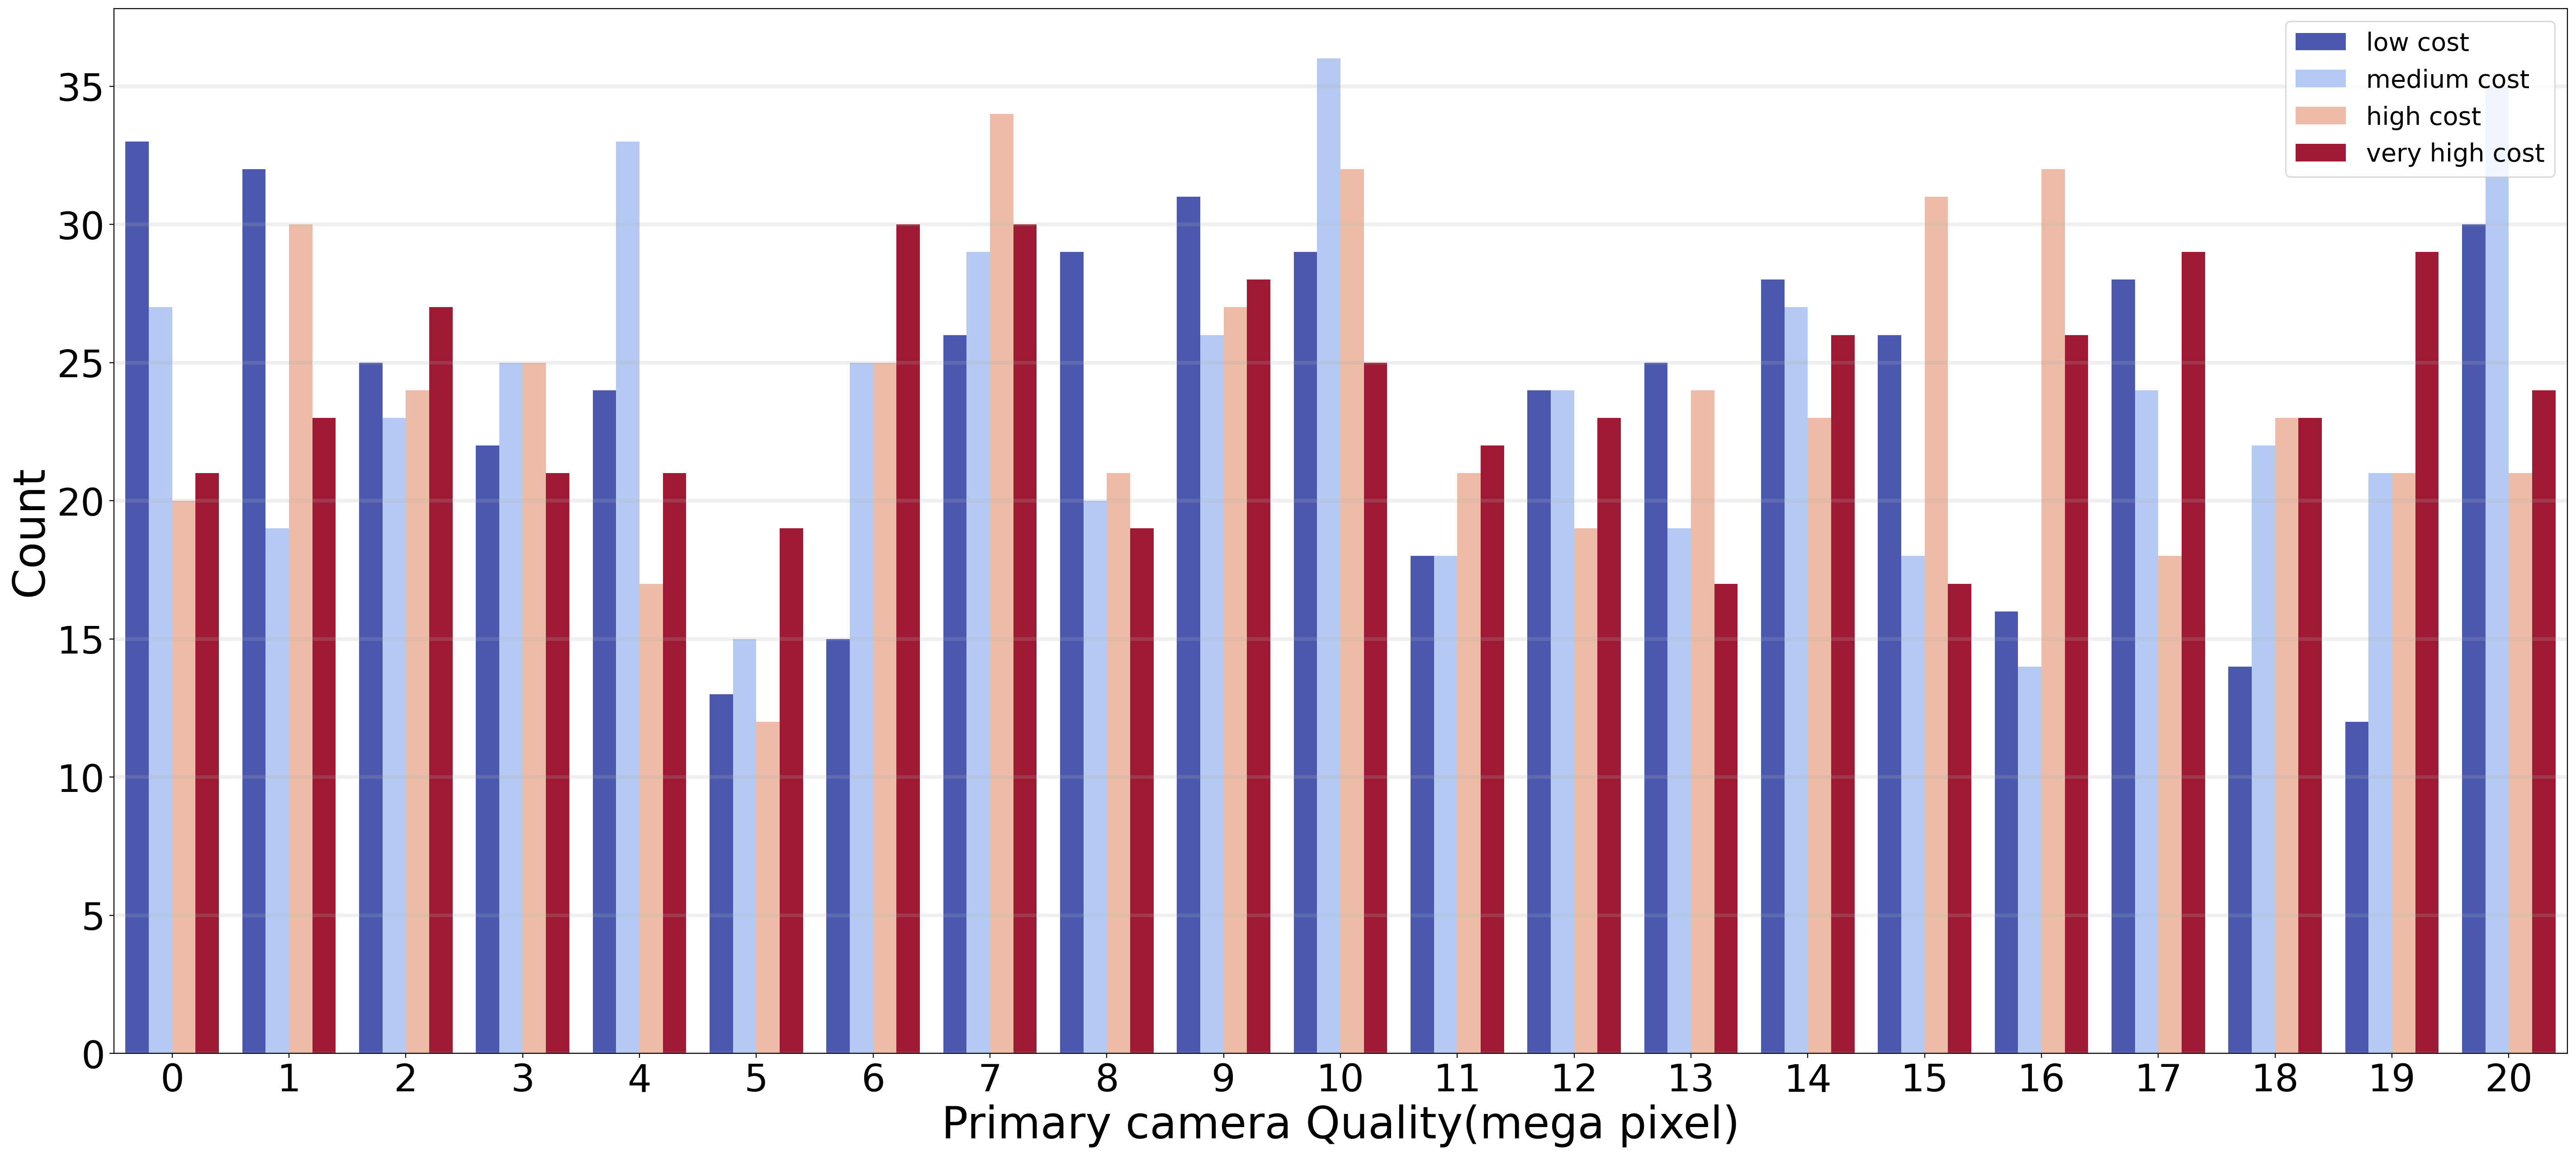

In [19]:
plt.figure(figsize=(35,15),dpi=200)
sns.countplot(data=df, x="pc", hue="price_range",stat="count",palette="coolwarm")
plt.xlabel("Primary camera Quality(mega pixel)",fontsize=35)
plt.ylabel("Count",fontsize=35)
plt.yticks(fontsize=30)
plt.xticks(fontsize=30)
plt.grid(linewidth=3,alpha=0.2,axis="y")
plt.legend(labels=["low cost","medium cost","high cost","very high cost"],loc="upper right",fontsize=20,title_fontsize=22,markerscale=3.5)
plt.show()

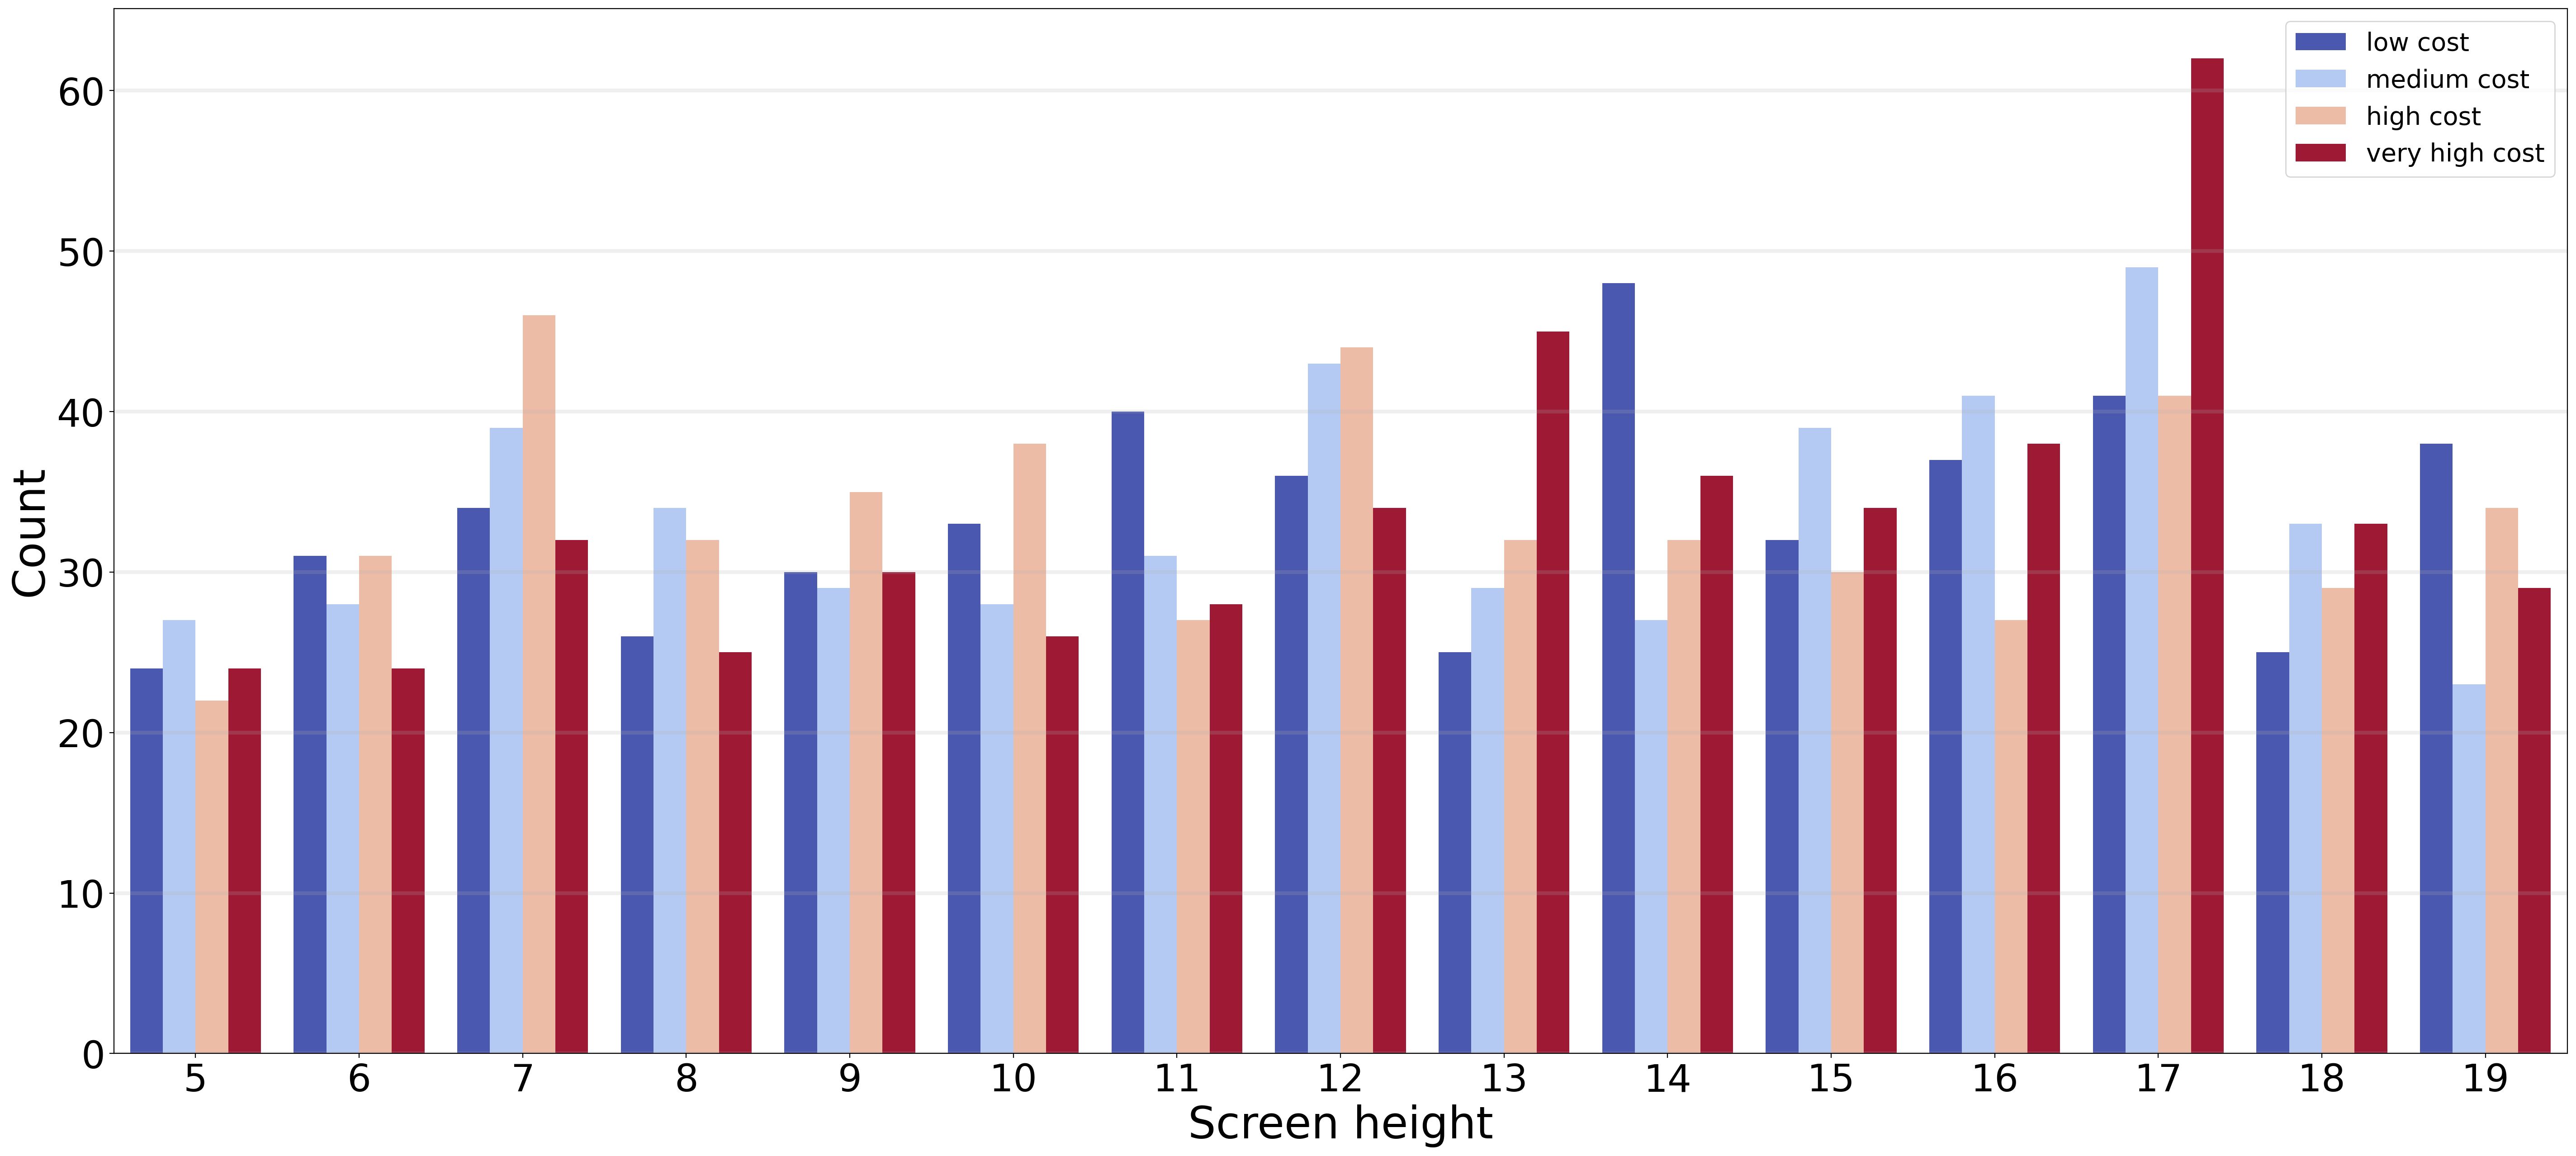

In [20]:
plt.figure(figsize=(35,15),dpi=200)
sns.countplot(data=df, x="sc_h", hue="price_range",stat="count",palette="coolwarm")
plt.xlabel("Screen height",fontsize=35)
plt.ylabel("Count",fontsize=35)
plt.yticks(fontsize=30)
plt.xticks(fontsize=30)
plt.grid(linewidth=3,alpha=0.2,axis="y")
plt.legend(labels=["low cost","medium cost","high cost","very high cost"],loc="upper right",fontsize=20,title_fontsize=22,markerscale=3.5)
plt.show()

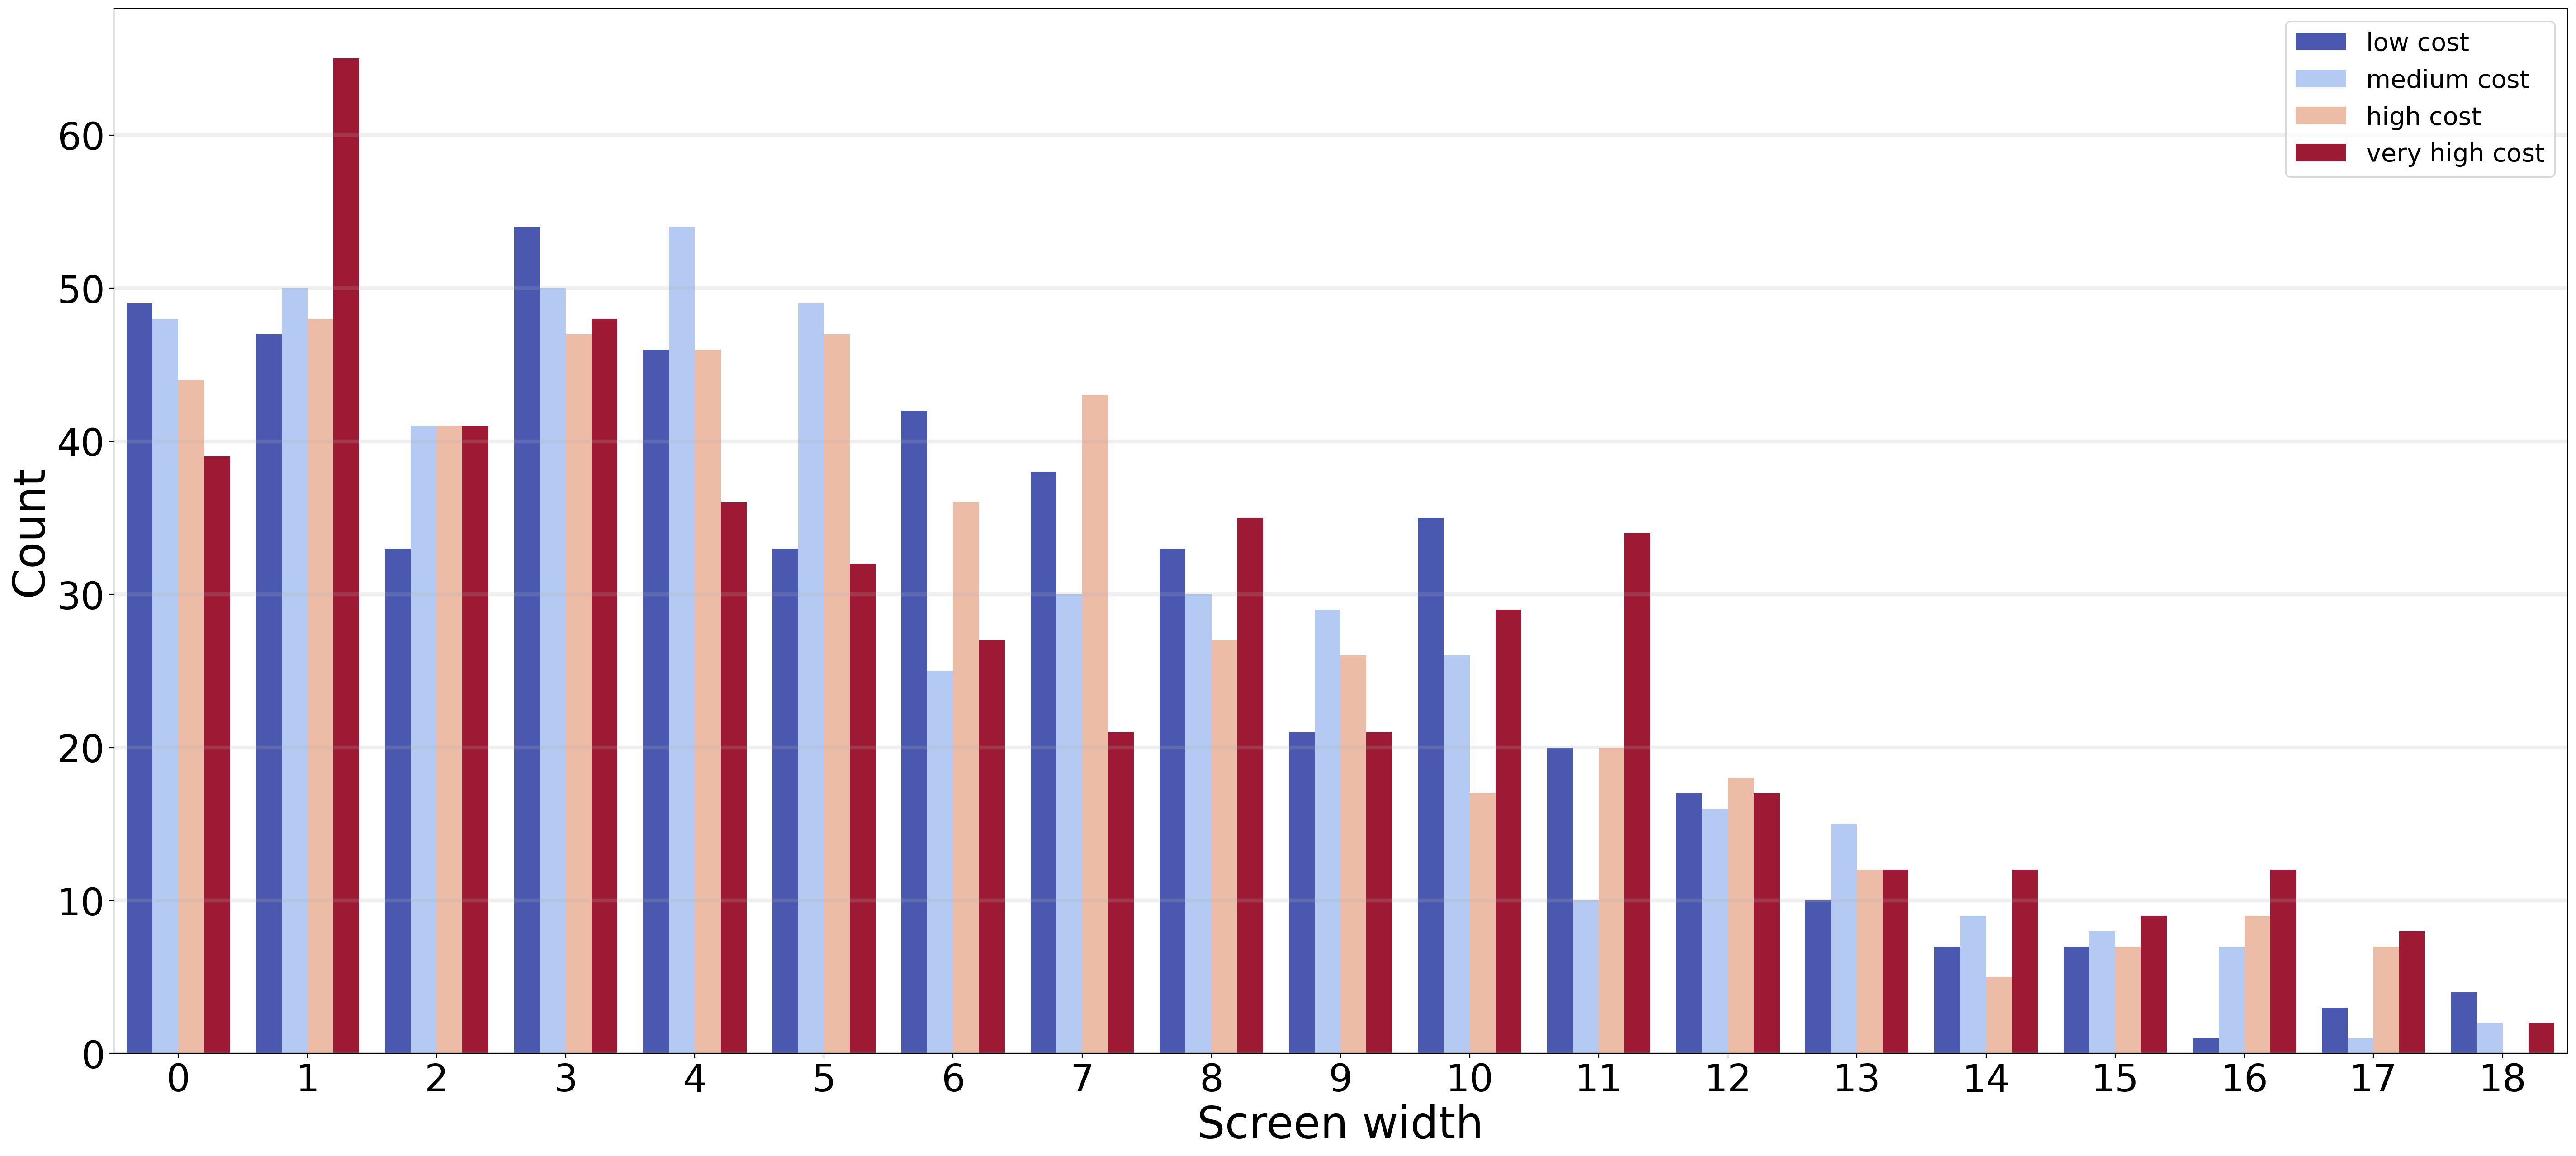

In [21]:
plt.figure(figsize=(35,15),dpi=200)
sns.countplot(data=df, x="sc_w", hue="price_range",stat="count",palette="coolwarm")
plt.xlabel("Screen width",fontsize=35)
plt.ylabel("Count",fontsize=35)
plt.yticks(fontsize=30)
plt.xticks(fontsize=30)
plt.grid(linewidth=3,alpha=0.2,axis="y")
plt.legend(labels=["low cost","medium cost","high cost","very high cost"],loc="upper right",fontsize=20,title_fontsize=22,markerscale=3.5)
plt.show()

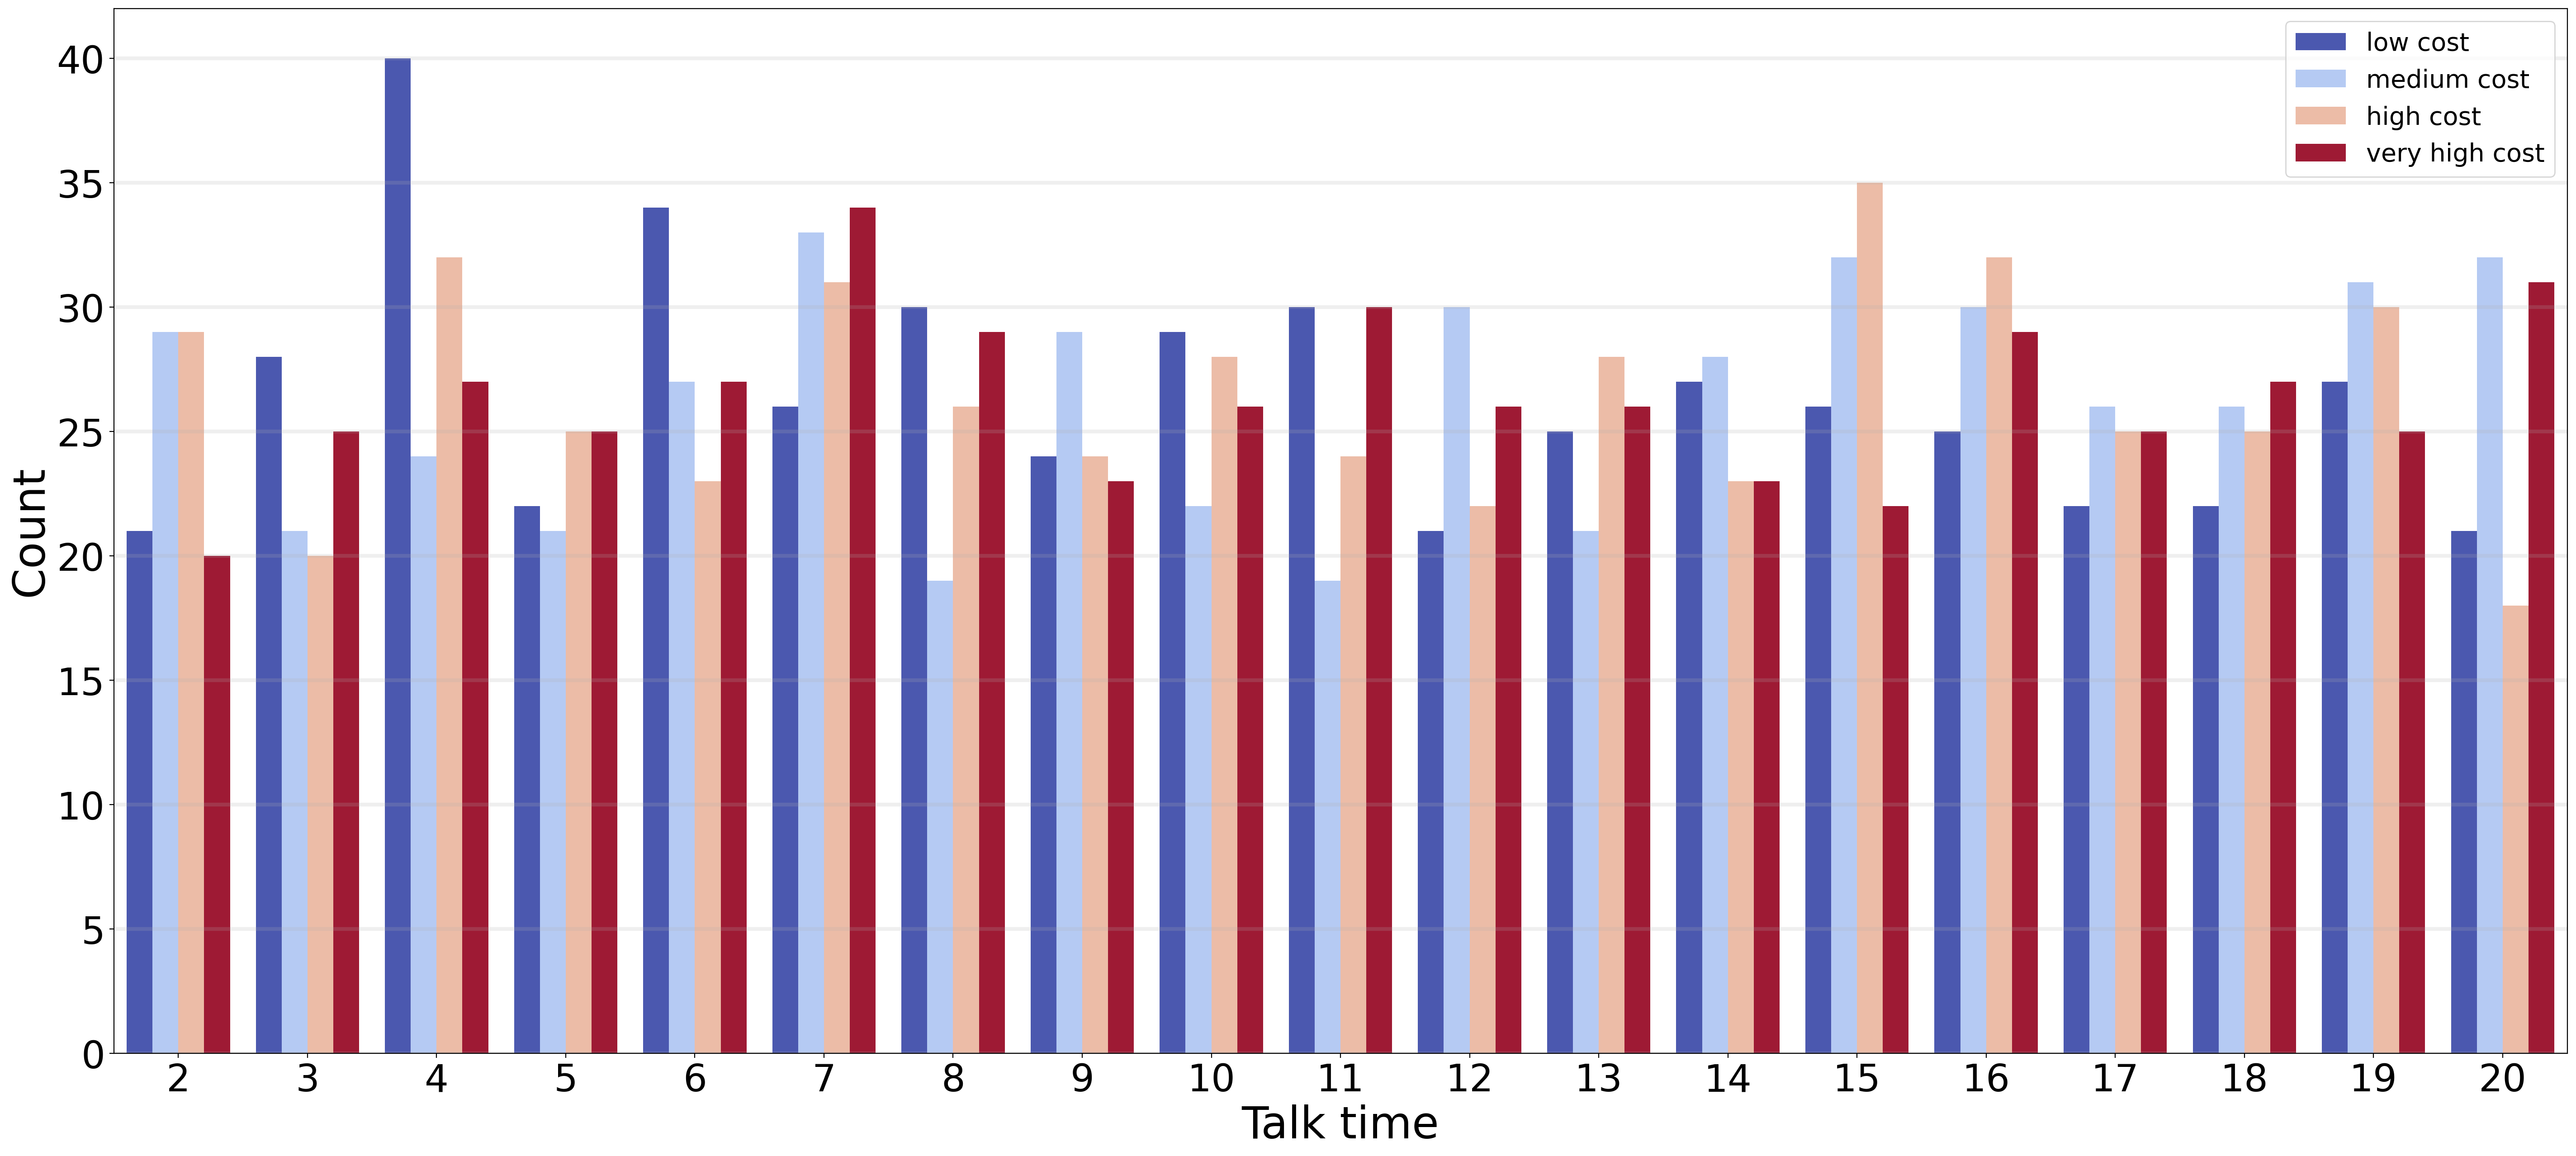

In [22]:
plt.figure(figsize=(35,15),dpi=200)
sns.countplot(data=df, x="talk_time", hue="price_range",stat="count",palette="coolwarm")
plt.xlabel("Talk time",fontsize=35)
plt.ylabel("Count",fontsize=35)
plt.yticks(fontsize=30)
plt.xticks(fontsize=30)
plt.grid(linewidth=3,alpha=0.2,axis="y")
plt.legend(labels=["low cost","medium cost","high cost","very high cost"],loc="upper right",fontsize=20,title_fontsize=22,markerscale=3.5)
plt.show()

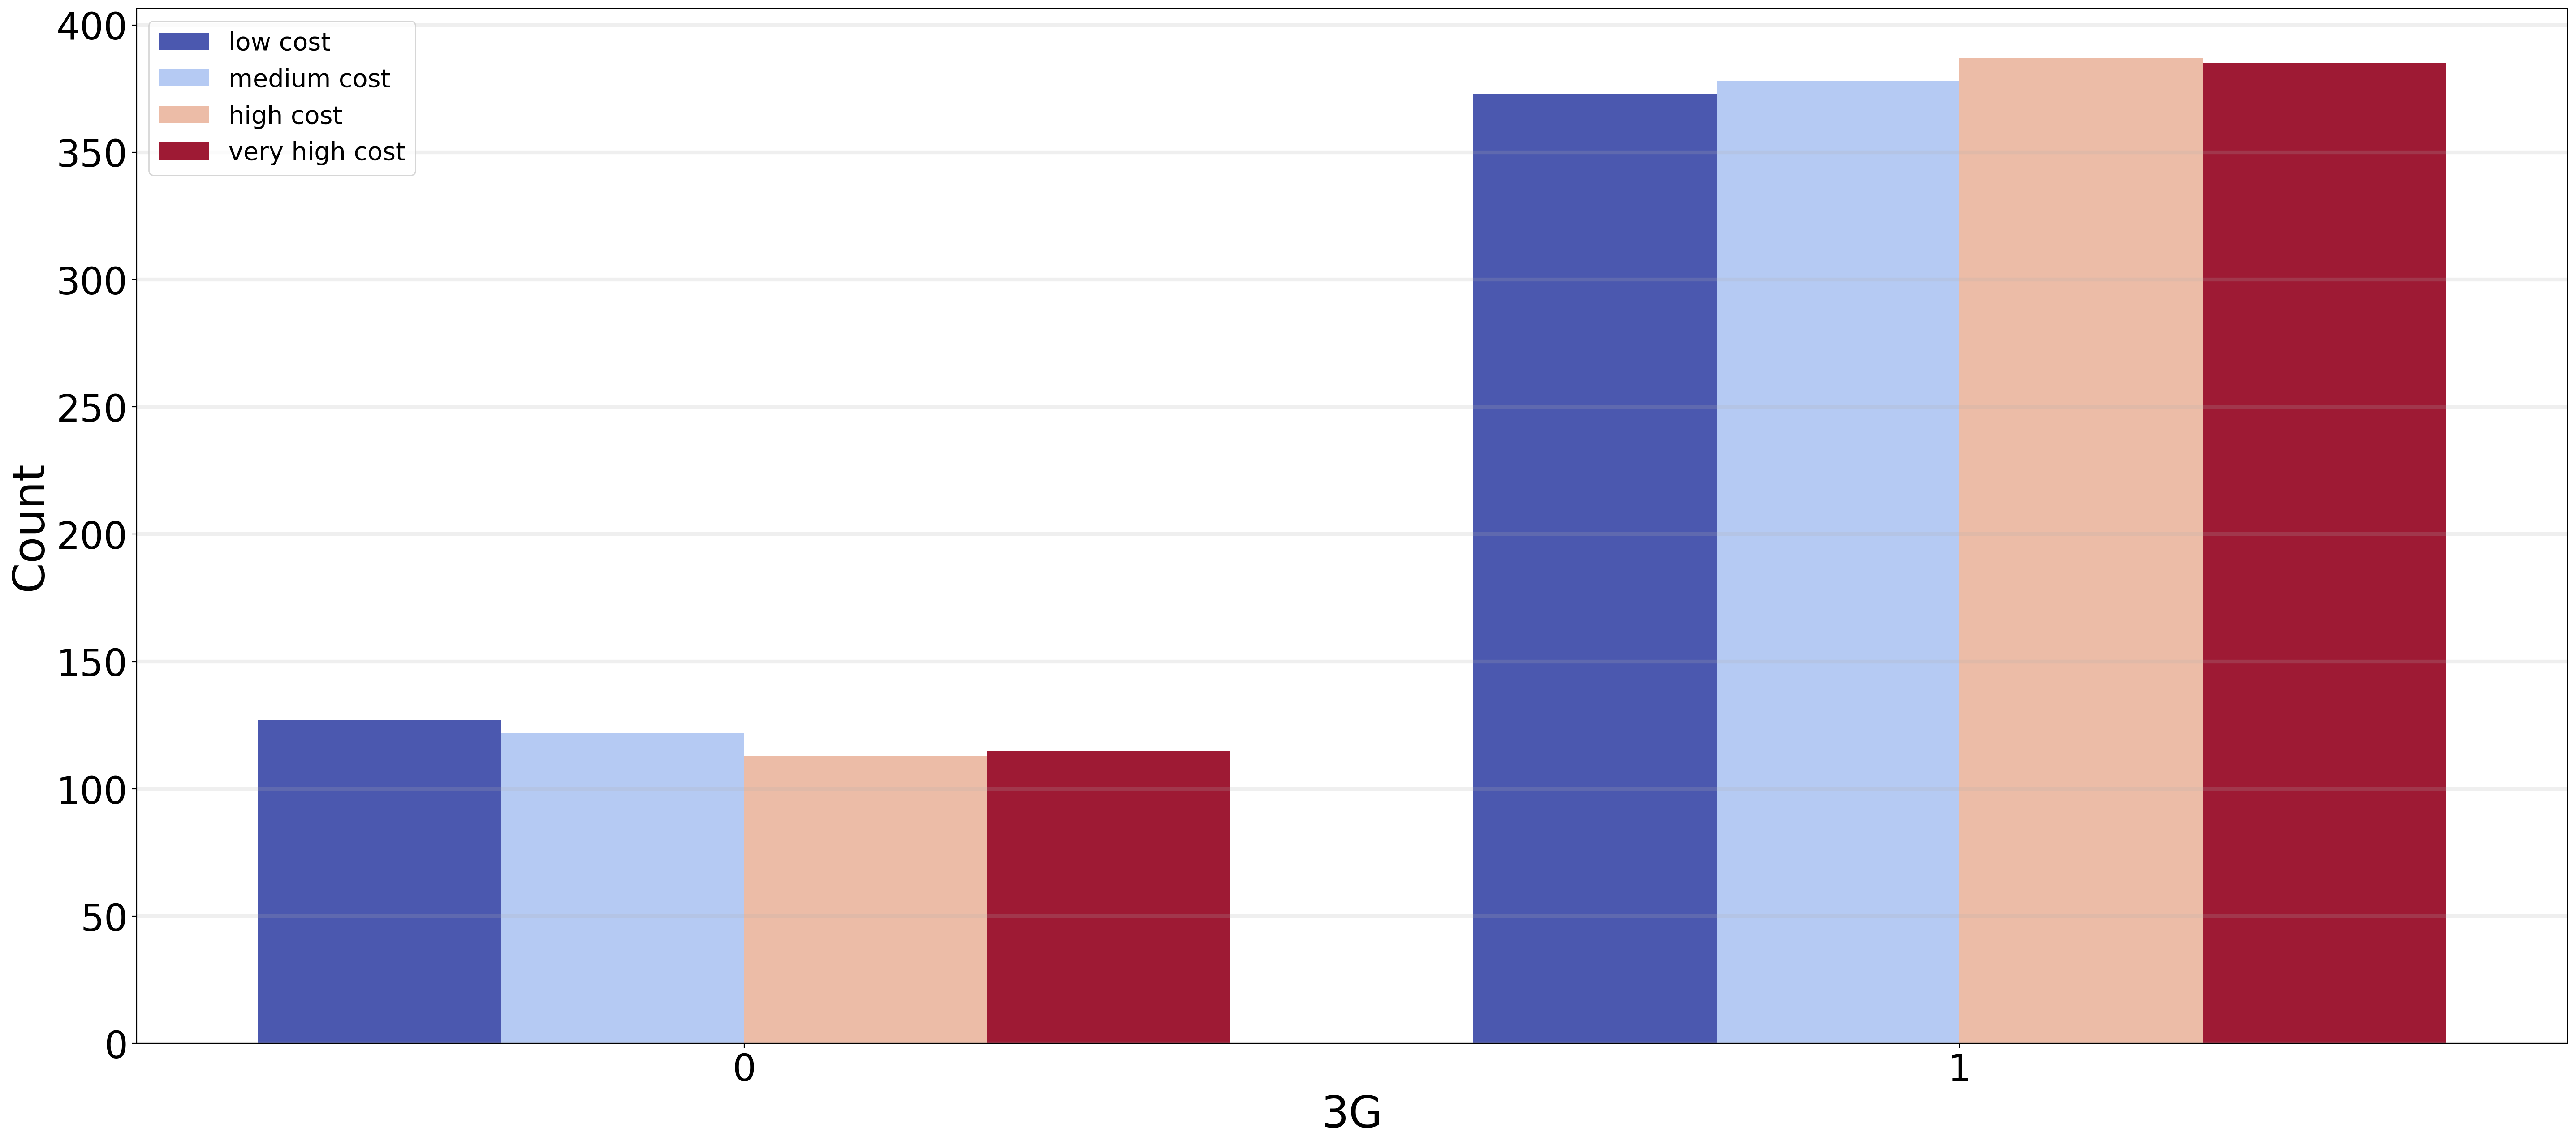

In [23]:
plt.figure(figsize=(35,15),dpi=200)
sns.countplot(data=df, x="three_g", hue="price_range",stat="count",palette="coolwarm")
plt.xlabel("3G",fontsize=35)
plt.ylabel("Count",fontsize=35)
plt.yticks(fontsize=30)
plt.xticks(fontsize=30)
plt.grid(linewidth=3,alpha=0.2,axis="y")
plt.legend(labels=["low cost","medium cost","high cost","very high cost"],loc="upper left",fontsize=20,title_fontsize=22,markerscale=3.5)
plt.show()

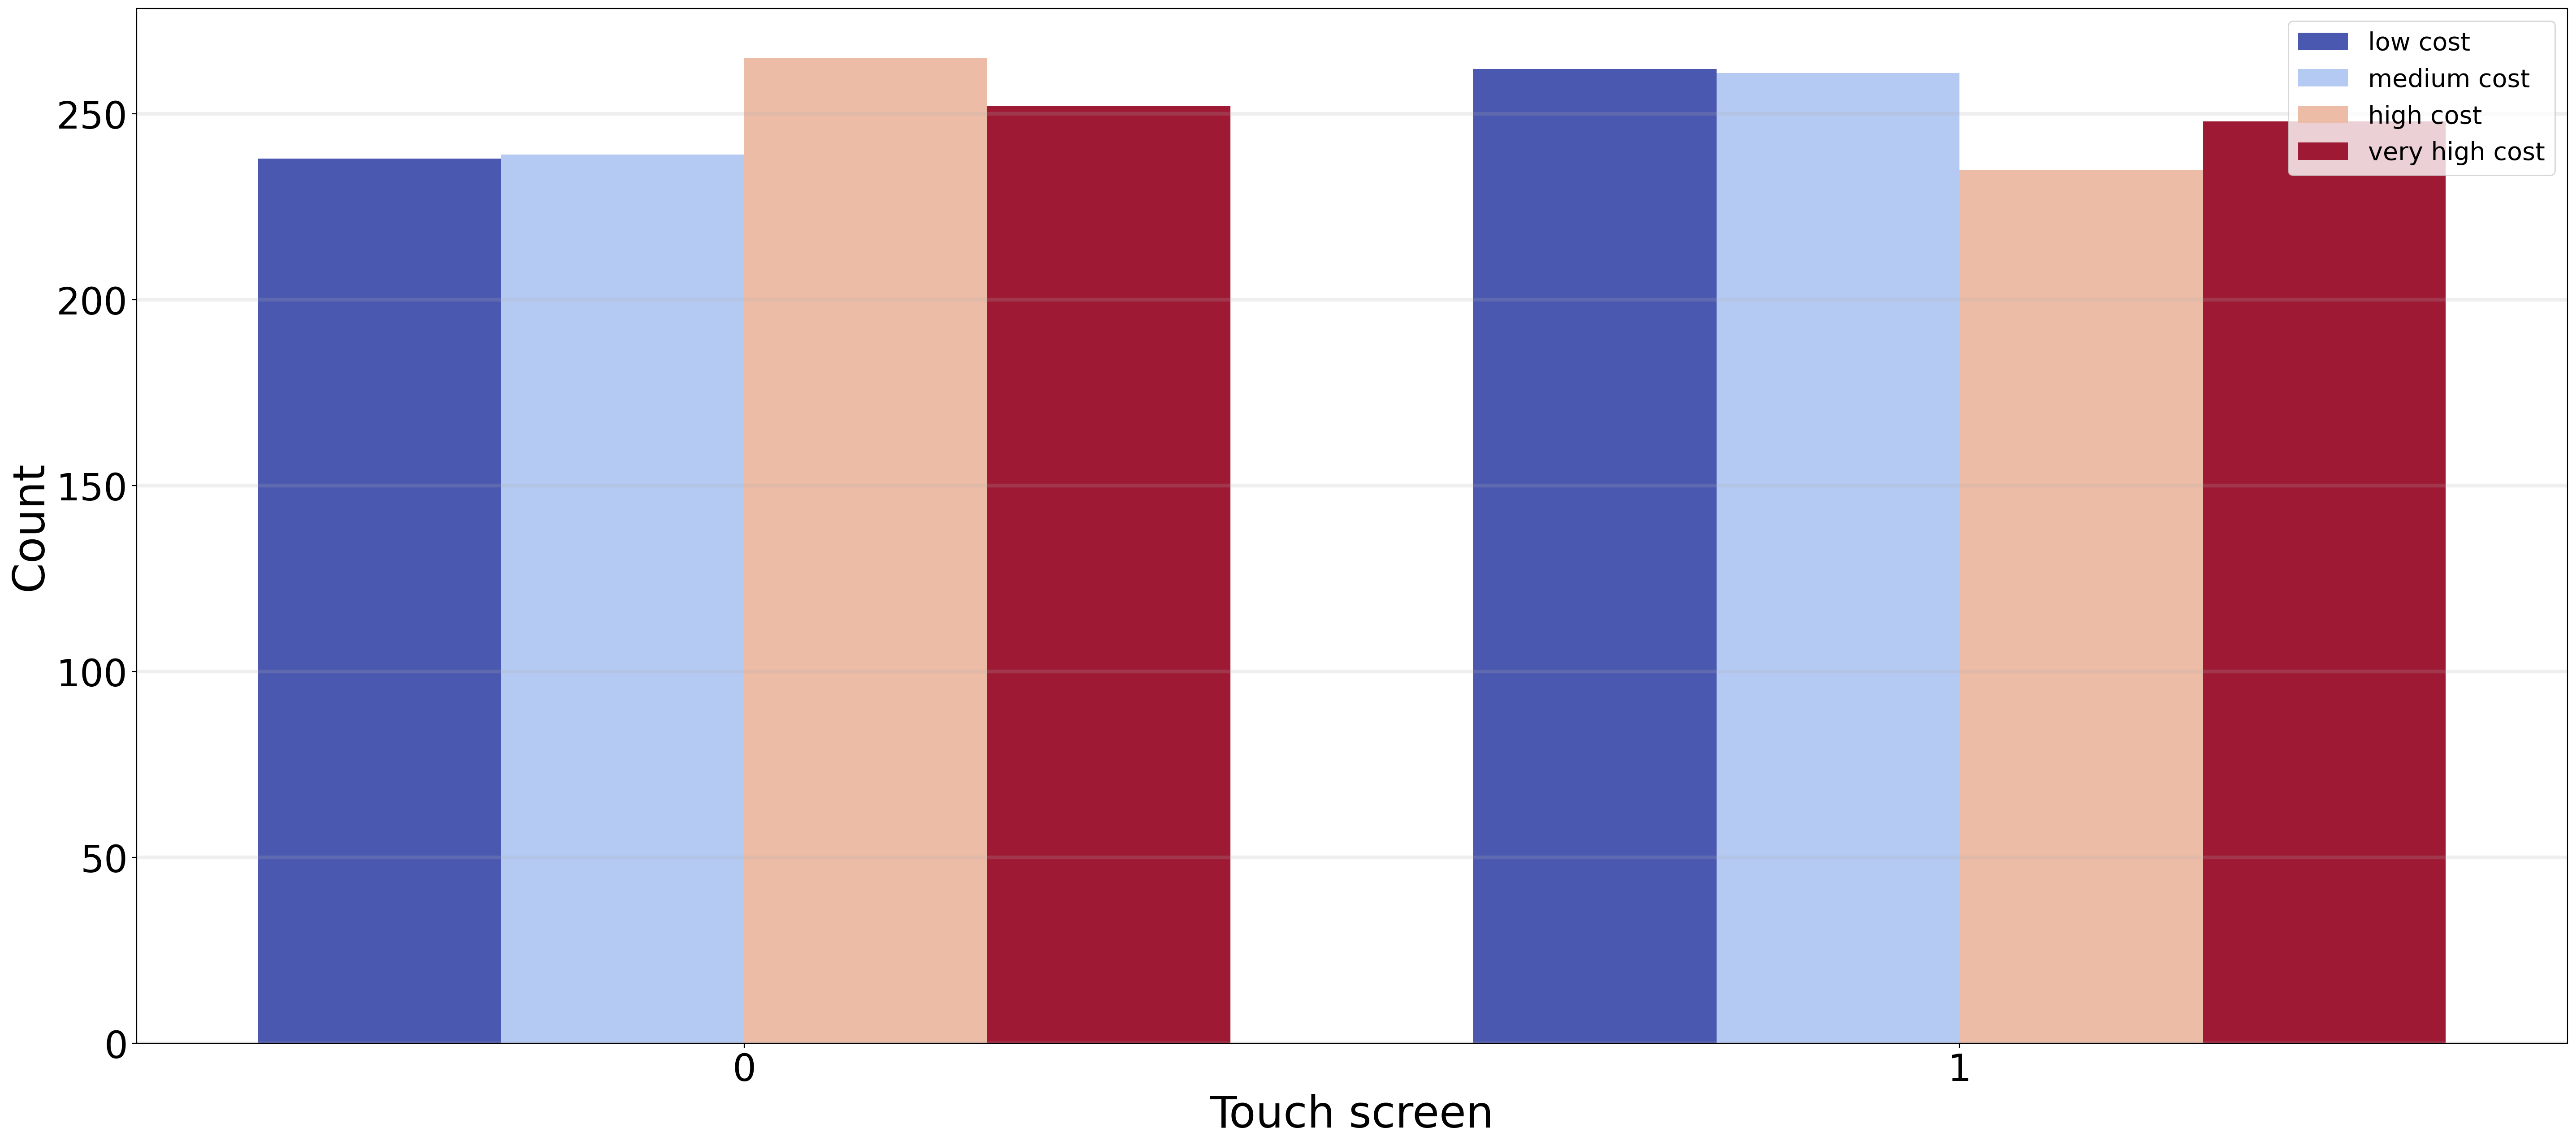

In [24]:
plt.figure(figsize=(35,15),dpi=200)
sns.countplot(data=df, x="touch_screen", hue="price_range",stat="count",palette="coolwarm")
plt.xlabel("Touch screen",fontsize=35)
plt.ylabel("Count",fontsize=35)
plt.yticks(fontsize=30)
plt.xticks(fontsize=30)
plt.grid(linewidth=3,alpha=0.2,axis="y")
plt.legend(labels=["low cost","medium cost","high cost","very high cost"],loc="upper right",fontsize=20,title_fontsize=22,markerscale=3.5)
plt.show()

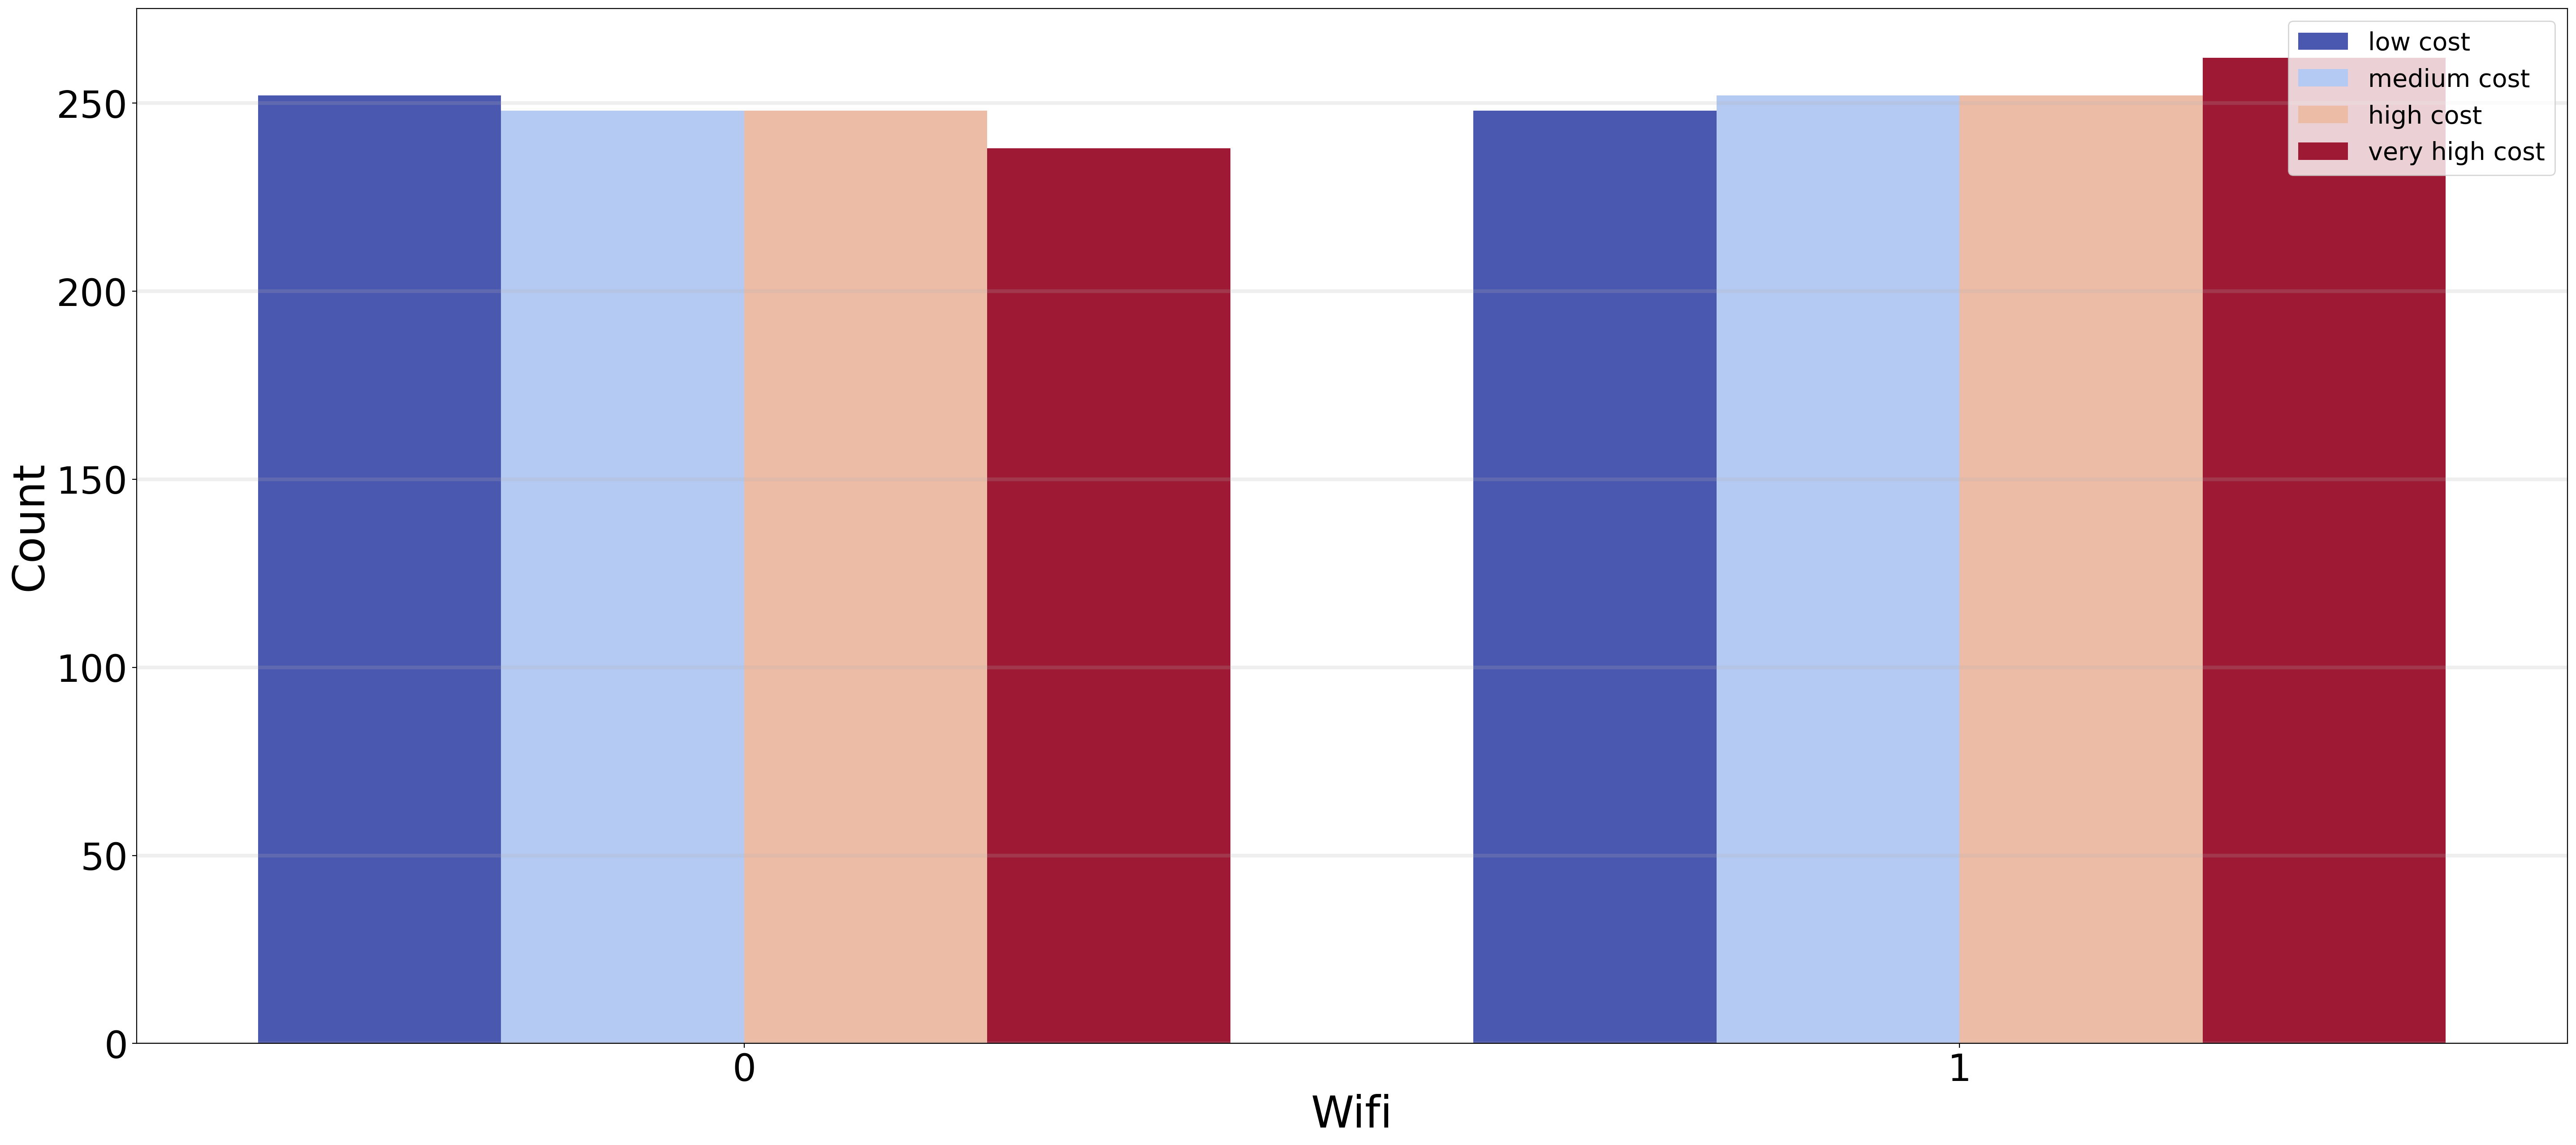

In [25]:
plt.figure(figsize=(35,15),dpi=200)
sns.countplot(data=df, x="wifi", hue="price_range",stat="count",palette="coolwarm")
plt.xlabel("Wifi",fontsize=35)
plt.ylabel("Count",fontsize=35)
plt.yticks(fontsize=30)
plt.xticks(fontsize=30)
plt.grid(linewidth=3,alpha=0.2,axis="y")
plt.legend(labels=["low cost","medium cost","high cost","very high cost"],loc="upper right",fontsize=20,title_fontsize=22,markerscale=3.5)
plt.show()

Text(0.5, 1.0, 'Battery power & Price range')

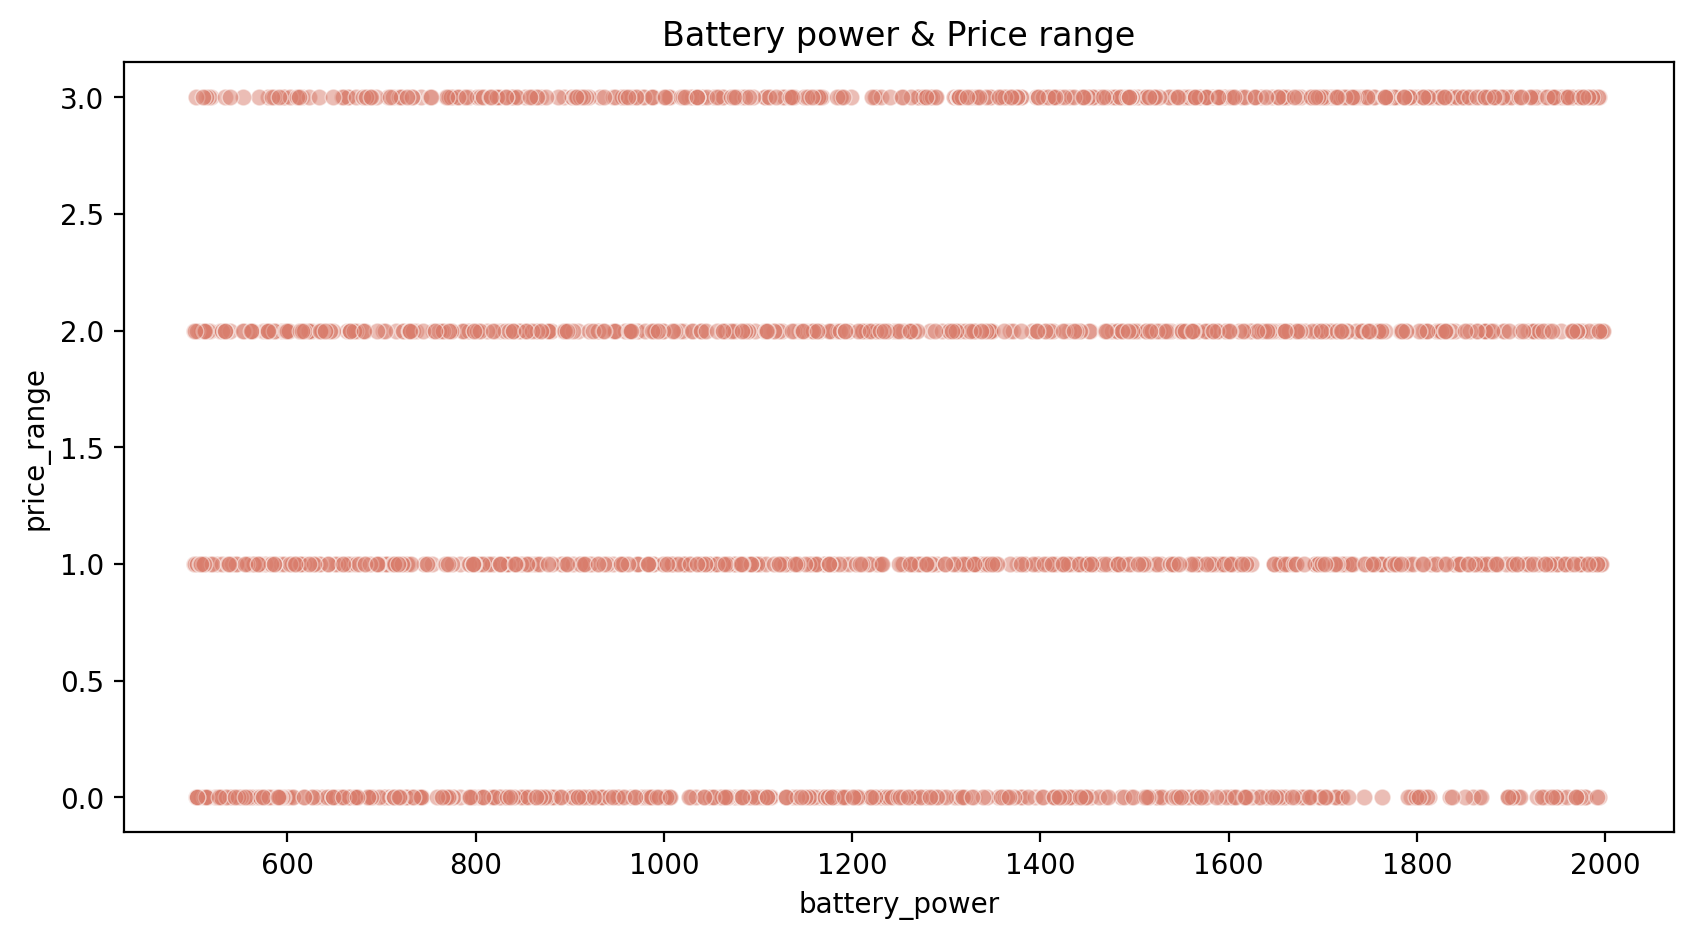

In [26]:
plt.figure(figsize=(10,5),dpi=200)
sns.scatterplot(data=df,x="battery_power",y="price_range",color="#d97d6c",alpha=0.5)
plt.title("Battery power & Price range")

<Figure size 2000x1000 with 0 Axes>

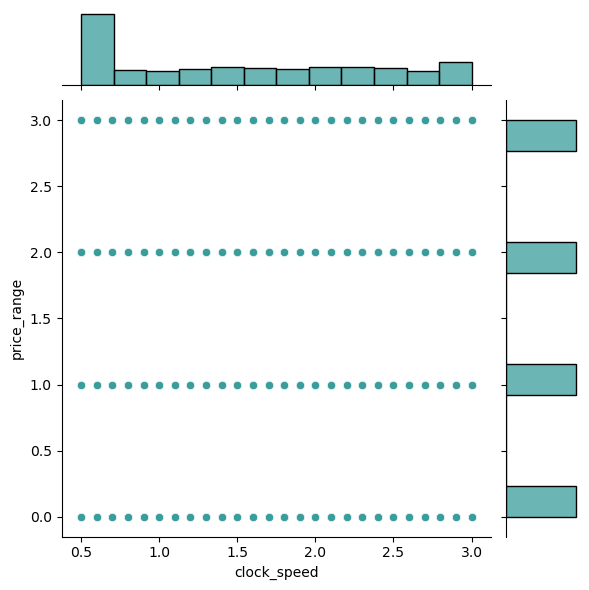

In [27]:
plt.figure(figsize=(10,5),dpi=200)
sns.jointplot(data=df,x="clock_speed",y="price_range",color="#3a9d9b")

<Figure size 2000x1000 with 0 Axes>

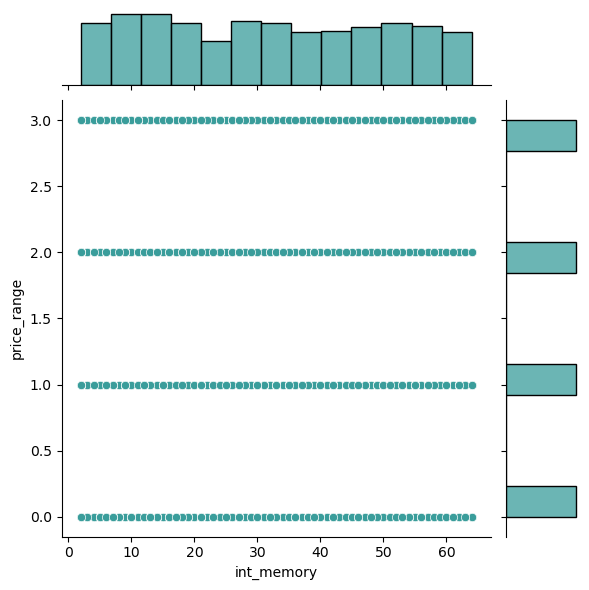

In [28]:
plt.figure(figsize=(10,5),dpi=200)
sns.jointplot(data=df,x="int_memory",y="price_range",color="#3a9d9b")

<Figure size 2000x1000 with 0 Axes>

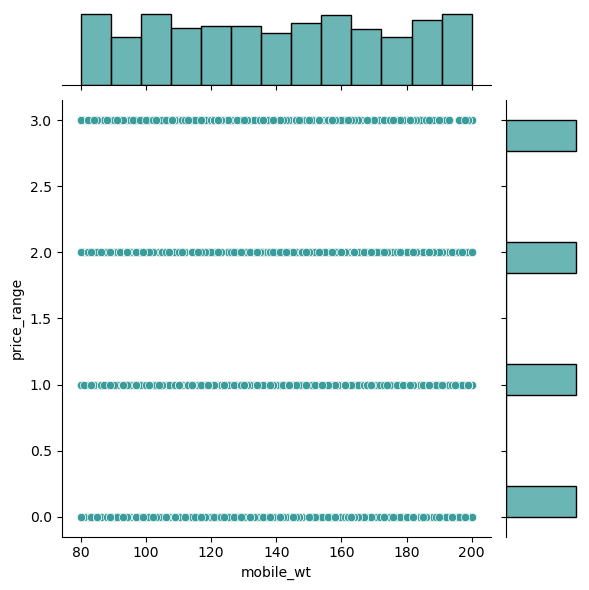

In [29]:
plt.figure(figsize=(10,5),dpi=200)
sns.jointplot(data=df,x="mobile_wt",y="price_range",color="#3a9d9b")

<span style="font-size:16px">Here we have some rows that i belive are miss information(noises).Because a phone cannot have<span style="color:red"> 0 </span>pixel resolution width and height </span>

<Figure size 2000x1000 with 0 Axes>

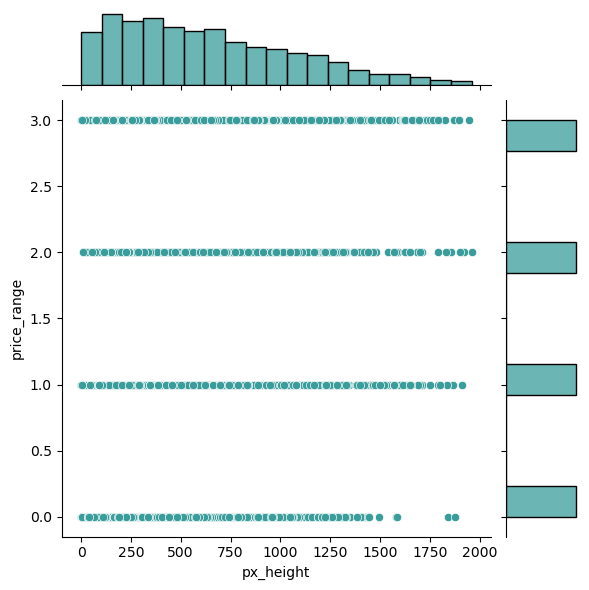

In [30]:
plt.figure(figsize=(10,5),dpi=200)
sns.jointplot(data=df,x="px_height",y="price_range",color="#3a9d9b")

<Figure size 2000x1000 with 0 Axes>

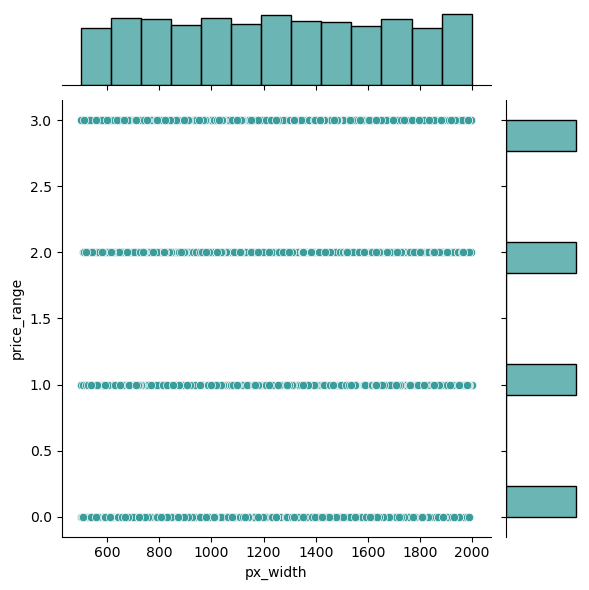

In [31]:
plt.figure(figsize=(10,5),dpi=200)
sns.jointplot(data=df,x="px_width",y="price_range",color="#3a9d9b")

<Figure size 2000x1000 with 0 Axes>

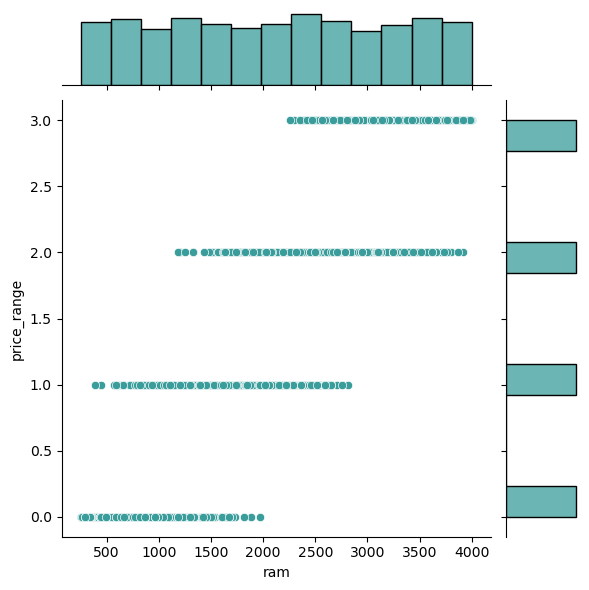

In [32]:
plt.figure(figsize=(10,5),dpi=200)
sns.jointplot(data=df,x="ram",y="price_range",color="#3a9d9b")

<span style="font-size:16px">In the plots there are some phones that dont have any camera.wich is highly unlikely because all phones have cameras in this day and age . </span>

In [33]:
print((df["px_height"]==0).sum())
print((df["sc_w"]==0).sum())
print((df["fc"]==0).sum())
print((df["pc"]==0).sum())

2
180
474
101


<span style="font-size:16px">according to the ressults of sum there is 575 rows of data without camera.Because this data set is old i decided to only delete the phones that have touchscreens and 4G without camera.Such a device is consider a smart phone and its imposible for a smart phone to not have cameras but in phones that dont support touch screen and dont have 4G technology its possible that it might be a normal phone without any options.so instade of deleteing most of our data i deleted 182 rows and 28 smartphones without cameras</span>

In [34]:
ms=len(df[(df["touch_screen"]==1)&((df["fc"]==0)&(df["pc"]==0))])
ms=ms+182
ms

233

In [35]:
(ms/len(df))*100

11.65

In [36]:
df=df[df["sc_w"]!=0]
df=df[df["px_height"]!=0]

In [37]:
df

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,...,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,...,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,...,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,...,1208,1212,1411,8,2,15,1,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,794,1,0.5,1,0,1,2,0.8,106,6,...,1222,1890,668,13,4,19,1,1,0,0
1996,1965,1,2.6,1,0,0,39,0.2,187,4,...,915,1965,2032,11,10,16,1,1,1,2
1997,1911,0,0.9,1,1,1,36,0.7,108,8,...,868,1632,3057,9,1,5,1,1,0,3
1998,1512,0,0.9,0,4,1,46,0.1,145,5,...,336,670,869,18,10,19,1,1,1,0


In [38]:
camera=((df["four_g"]==1)&
        (df["touch_screen"]==1)&
        (df["pc"]==0)&
        (df["fc"]==0))

In [39]:
camera.sum()

np.int64(28)

In [40]:
df=df[~camera].reset_index(drop=True)

In [41]:
df

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,...,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,...,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,...,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,...,1208,1212,1411,8,2,15,1,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1786,794,1,0.5,1,0,1,2,0.8,106,6,...,1222,1890,668,13,4,19,1,1,0,0
1787,1965,1,2.6,1,0,0,39,0.2,187,4,...,915,1965,2032,11,10,16,1,1,1,2
1788,1911,0,0.9,1,1,1,36,0.7,108,8,...,868,1632,3057,9,1,5,1,1,0,3
1789,1512,0,0.9,0,4,1,46,0.1,145,5,...,336,670,869,18,10,19,1,1,1,0


In [42]:
df["blue"]=df["blue"].replace([0,1],[2,3])
df["dual_sim"]=df["dual_sim"].replace([0,1],[2,3])
df["four_g"]=df["four_g"].replace([0,1],[2,3])
df["three_g"]=df["three_g"].replace([0,1],[2,3])
df["touch_screen"]=df["touch_screen"].replace([0,1],[2,3])
df["wifi"]=df["wifi"].replace([0,1],[2,3])
test_df["blue"]=test_df["blue"].replace([0,1],[2,3])
test_df["dual_sim"]=test_df["dual_sim"].replace([0,1],[2,3])
test_df["four_g"]=test_df["four_g"].replace([0,1],[2,3])
test_df["three_g"]=test_df["three_g"].replace([0,1],[2,3])
test_df["touch_screen"]=test_df["touch_screen"].replace([0,1],[2,3])
test_df["wifi"]=test_df["wifi"].replace([0,1],[2,3])

In [43]:
df

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,2,2.2,2,1,2,7,0.6,188,2,...,20,756,2549,9,7,19,2,2,3,1
1,1021,3,0.5,3,0,3,53,0.7,136,3,...,905,1988,2631,17,3,7,3,3,2,2
2,563,3,0.5,3,2,3,41,0.9,145,5,...,1263,1716,2603,11,2,9,3,3,2,2
3,615,3,2.5,2,0,2,10,0.8,131,6,...,1216,1786,2769,16,8,11,3,2,2,2
4,1821,3,1.2,2,13,3,44,0.6,141,2,...,1208,1212,1411,8,2,15,3,3,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1786,794,3,0.5,3,0,3,2,0.8,106,6,...,1222,1890,668,13,4,19,3,3,2,0
1787,1965,3,2.6,3,0,2,39,0.2,187,4,...,915,1965,2032,11,10,16,3,3,3,2
1788,1911,2,0.9,3,1,3,36,0.7,108,8,...,868,1632,3057,9,1,5,3,3,2,3
1789,1512,2,0.9,2,4,3,46,0.1,145,5,...,336,670,869,18,10,19,3,3,3,0


<h2>Functions</h2>
<span style="font-size:16px">In these cells i like to keep my functions just to keep them away from main codes</span>

In [44]:
def feature_selection(score,xd,yd,data,test_data,target,size,model,r2=False,scaler=True):
    test_score=score
    for i in data.columns:
        if i == target:
            continue
        else:
            new_name=i+"2"
            new_value=data[i]**2
            xd.insert(0,new_name,new_value)
            if scaler :
                xscaled2=scale(xd)
                x_train2,x_test2,y_train2,y_test2=train_test_split(xscaled2,yd.ravel(),test_size=size,random_state=0)
            else:
                x_train2,x_test2,y_train2,y_test2=train_test_split(xd,yd.ravel(),test_size=size,random_state=0)
            model.fit(x_train2,y_train2)
            y_pred2=model.predict(x_test2)
            if r2:
                new_score=metrics.r2_score(y_test2,y_pred2)   
            else:    
                new_score=model.score(x_test2,y_test2)
            if new_score>test_score:
                test_score=new_score
                data.insert(0,new_name,new_value)
                test_data.insert(0,new_name,test_data[i]**2)
                
            else:
                xd.drop([new_name],axis=1,inplace=True)
                if scaler:
                    xscaled2=scale(xd)
                    x_train2,x_test2,y_train2,y_test2=train_test_split(xscaled2,yd.ravel(),test_size=size,random_state=0)
                else:
                    x_train2,x_test2,y_train2,y_test2=train_test_split(xd,yd.ravel(),test_size=size,random_state=0)            
                model.fit(x_train2,y_train2)
                y_pred2=model.predict(x_test2)
        print(test_score,"\n",xd.columns,"\n")

In [45]:
scaler=StandardScaler()
def scale(sample,is_user=False):
    if is_user:
        return scaler.transform(sample)
    else:
        return scaler.fit_transform(sample)

In [46]:
def tree (sx,sy,depth,size):
    results=[]
    for i in size:
        x_train,x_test,y_train,y_test=train_test_split(sx,sy,test_size=i,random_state=0)
        for j in depth:
            clf=DecisionTreeClassifier(max_depth=j,criterion="entropy")
            clf.fit(x_train,y_train)
            y_pred=clf.predict(x_test)
            outcome={"test size":i,"max depth":j,"accuracy":metrics.accuracy_score(y_test,y_pred)
                     ,"score":clf.score(sx,sy)}
            results.append(outcome)
    return(pd.DataFrame(results))

In [47]:
def forest (sx,sy,size,depth):
    results=[]
    for i in size:
        x_train,x_test,y_train,y_test=train_test_split(sx,sy,test_size=i,random_state=0)
        for j in depth:
            rf=RandomForestClassifier(max_depth=j,criterion="entropy")
            rf.fit(x_train,y_train)
            y_pred=rf.predict(x_test)
            outcome={"test size":i,"max depth":j,"accuracy":metrics.accuracy_score(y_test,y_pred)
                     ,"score":rf.score(sx,sy)}
            results.append(outcome)
    return(pd.DataFrame(results))


In [48]:
def leaf(sx,sy,size,depth,leafs):
    results=[]
    x_train,x_test,y_train,y_test=train_test_split(sx,sy,test_size=size,random_state=0)
    for i in leafs:
        rf=RandomForestClassifier(max_depth=depth,min_samples_leaf=i,criterion="entropy")
        rf.fit(x_train,y_train)
        y_pred=rf.predict(x_test)
        outcome={"accuracy":metrics.accuracy_score(y_test,y_pred),"score":rf.score(x_test,y_test)}
        results.append(outcome)
    return (pd.DataFrame(results))

<h2>Decision Tree</h2>

In [49]:
x=df.drop("price_range",axis=1)
y=df["price_range"].values.reshape(-1,1)

<span style="font-size:16px">This first model uses a tree function to help us to find the best outcome.this function modifies max_depth and test size.for criterion <span style="color:blue">"entropy"</span> results were beter than <span style="color:blue">"gini".</span></span>

In [50]:
model=tree(x,y,[1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25],[0.1,0.15,0.2,0.25,0.3])
model.style.background_gradient(subset=["accuracy","score"],cmap="Greens")

,test size,max depth,accuracy,score
0,0.100000,1,0.522222,0.500838
1,0.100000,2,0.811111,0.762702
2,0.100000,3,0.811111,0.762702
3,0.100000,4,0.794444,0.808487
4,0.100000,5,0.844444,0.862088
5,0.100000,6,0.888889,0.913456
6,0.100000,7,0.877778,0.944724
7,0.100000,8,0.872222,0.965941
8,0.100000,9,0.877778,0.982691
9,0.100000,10,0.877778,0.987716


In [51]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.1,random_state=0)
clf=DecisionTreeClassifier(max_depth=11,criterion="entropy")
clf.fit(x_train,y_train)
y_pred=clf.predict(x_test)

<span style="font-size:16px">This model is over fited because its performance on unseen data is low and it just memorized from train test.</span>

In [52]:
print(f"train score:{clf.score(x_train,y_train)}\ntest score:{clf.score(x_test,y_test)}")

train score:1.0
test score:0.9


In [53]:
print(metrics.classification_report(y,clf.predict(x)))

              precision    recall  f1-score   support

           0       0.99      1.00      1.00       441
           1       0.99      0.98      0.99       443
           2       0.98      0.99      0.98       451
           3       0.99      0.99      0.99       456

    accuracy                           0.99      1791
   macro avg       0.99      0.99      0.99      1791
weighted avg       0.99      0.99      0.99      1791



In [54]:
metrics.confusion_matrix(y,clf.predict(x))

array([[440,   1,   0,   0],
       [  3, 436,   4,   0],
       [  0,   2, 446,   3],
       [  0,   0,   5, 451]])

<span style="font-size:16px">Grid search didnt improve the model well enough but the overfiting problem is gone with this leaf number and max depth.</span>

In [55]:
params={"max_depth":range(1,20),
       "min_samples_leaf":range(1,20),
       "criterion":["gini","entropy"],
       "ccp_alpha":[0,0.001,0.005,0.01]}
gs=GridSearchCV(DecisionTreeClassifier(random_state=0),params,cv=5,n_jobs=2)
gs.fit(x_train,y_train)
print(gs.best_params_,"\n",gs.best_score_)

{'ccp_alpha': 0, 'criterion': 'entropy', 'max_depth': 10, 'min_samples_leaf': 1} 
 0.8485414303020979


<span style="font-size:16px">Here with use of K fold we can try to remove bad samples from data</span>

In [56]:
k=20
print(cross_val_score(clf,x,y,cv=k))

[0.92222222 0.82222222 0.81111111 0.82222222 0.83333333 0.84444444
 0.81111111 0.86666667 0.83333333 0.88888889 0.85555556 0.84269663
 0.8988764  0.91011236 0.87640449 0.84269663 0.79775281 0.85393258
 0.78651685 0.83146067]


In [57]:
len(df)/k

89.55

In [58]:
fold1=df[df.index<1611]
fold2=df[df.index>1701]
df_folded=pd.concat([fold1,fold2]).reset_index(drop=True)

In [59]:
df_folded

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,2,2.2,2,1,2,7,0.6,188,2,...,20,756,2549,9,7,19,2,2,3,1
1,1021,3,0.5,3,0,3,53,0.7,136,3,...,905,1988,2631,17,3,7,3,3,2,2
2,563,3,0.5,3,2,3,41,0.9,145,5,...,1263,1716,2603,11,2,9,3,3,2,2
3,615,3,2.5,2,0,2,10,0.8,131,6,...,1216,1786,2769,16,8,11,3,2,2,2
4,1821,3,1.2,2,13,3,44,0.6,141,2,...,1208,1212,1411,8,2,15,3,3,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1695,794,3,0.5,3,0,3,2,0.8,106,6,...,1222,1890,668,13,4,19,3,3,2,0
1696,1965,3,2.6,3,0,2,39,0.2,187,4,...,915,1965,2032,11,10,16,3,3,3,2
1697,1911,2,0.9,3,1,3,36,0.7,108,8,...,868,1632,3057,9,1,5,3,3,2,3
1698,1512,2,0.9,2,4,3,46,0.1,145,5,...,336,670,869,18,10,19,3,3,3,0


In [60]:
x=df_folded.drop("price_range",axis=1)
y=df_folded["price_range"].values.reshape(-1,1)
xscaled=scale(x)

In [61]:
folded_model=tree(x,y,[1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25],[0.1,0.15,0.2,0.25,0.3])
folded_model.style.background_gradient(subset=["accuracy","score"],cmap="Greens")

,test size,max depth,accuracy,score
0,0.100000,1,0.535294,0.494706
1,0.100000,2,0.705882,0.755882
2,0.100000,3,0.705882,0.755882
3,0.100000,4,0.776471,0.826471
4,0.100000,5,0.805882,0.868235
5,0.100000,6,0.823529,0.912353
6,0.100000,7,0.847059,0.942941
7,0.100000,8,0.805882,0.965882
8,0.100000,9,0.800000,0.977647
9,0.100000,10,0.817647,0.981176


In [62]:
x_train,x_test,y_train,y_test=train_test_split(xscaled,y,test_size=0.15,random_state=0)
clf=DecisionTreeClassifier(max_depth=14,criterion="entropy")
clf.fit(x_train,y_train)
y_pred=clf.predict(x_test)

In [63]:
print(metrics.classification_report(y,clf.predict(xscaled)))

              precision    recall  f1-score   support

           0       0.99      0.98      0.98       408
           1       0.97      0.98      0.97       427
           2       0.98      0.97      0.97       431
           3       0.99      0.99      0.99       434

    accuracy                           0.98      1700
   macro avg       0.98      0.98      0.98      1700
weighted avg       0.98      0.98      0.98      1700



<span style="font-size:16px">K fold dosent work either.one thing  we can do is to select the lower max depth with a good score i took 9 i used it on the unfolded data .The reason is K fold in my opinion is not a very good method of improvement.in real world bad datas will allways exist so we must train our model in a way to handel those kind of data.</span>

In [64]:
print(clf.score(x_train,y_train))
print(clf.score(x_test,y_test))
print(metrics.accuracy_score(y_test,y_pred))

1.0
0.8627450980392157
0.8627450980392157


In [65]:
metrics.confusion_matrix(y,clf.predict(xscaled))

array([[401,   7,   0,   0],
       [  6, 417,   4,   0],
       [  0,   6, 419,   6],
       [  0,   0,   6, 428]])

In [66]:
x=df.drop("price_range",axis=1)
y=df["price_range"].values.reshape(-1,1)
xscaled=scale(x)

In [67]:
x_train,x_test,y_train,y_test=train_test_split(xscaled,y,test_size=0.1,random_state=0)
clf=DecisionTreeClassifier(max_depth=9,min_samples_leaf=5,criterion="entropy",ccp_alpha=0)
clf.fit(x_train,y_train)
y_pred=clf.predict(x_test)

<span style="font-size:16px">Good results so far overfiting is gone.</span>

In [68]:
print(f"train score:{clf.score(x_train,y_train)}\ntest score:{clf.score(x_test,y_test)}")

train score:0.9515828677839852
test score:0.8666666666666667


In [69]:
print(metrics.classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.90      0.96      0.93        46
           1       0.88      0.78      0.82        45
           2       0.76      0.85      0.80        41
           3       0.93      0.88      0.90        48

    accuracy                           0.87       180
   macro avg       0.87      0.87      0.86       180
weighted avg       0.87      0.87      0.87       180



In [70]:
print(metrics.confusion_matrix(y_test,y_pred))

[[44  2  0  0]
 [ 5 35  5  0]
 [ 0  3 35  3]
 [ 0  0  6 42]]


<span style="font-size:16px">Using the feature selection function can help  us improve the model too.</span>

In [71]:
x_dts=df.drop("price_range",axis=1)
y_dts=df["price_range"].values.reshape(-1,1)

In [72]:
dts_moded_test_df=test_df.copy()
dts_moded_df=df.copy()

In [73]:
feature_selection(0.8666666666666667,x_dts,y_dts,dts_moded_df,dts_moded_test_df
                  ,"price_range",0.2,DecisionTreeClassifier(max_depth=9,min_samples_leaf=5,
                   criterion="entropy",ccp_alpha=0))

0.8666666666666667 
 Index(['battery_power', 'blue', 'clock_speed', 'dual_sim', 'fc', 'four_g',
       'int_memory', 'm_dep', 'mobile_wt', 'n_cores', 'pc', 'px_height',
       'px_width', 'ram', 'sc_h', 'sc_w', 'talk_time', 'three_g',
       'touch_screen', 'wifi'],
      dtype='object') 

0.871866295264624 
 Index(['blue2', 'battery_power', 'blue', 'clock_speed', 'dual_sim', 'fc',
       'four_g', 'int_memory', 'm_dep', 'mobile_wt', 'n_cores', 'pc',
       'px_height', 'px_width', 'ram', 'sc_h', 'sc_w', 'talk_time', 'three_g',
       'touch_screen', 'wifi'],
      dtype='object') 

0.871866295264624 
 Index(['blue2', 'battery_power', 'blue', 'clock_speed', 'dual_sim', 'fc',
       'four_g', 'int_memory', 'm_dep', 'mobile_wt', 'n_cores', 'pc',
       'px_height', 'px_width', 'ram', 'sc_h', 'sc_w', 'talk_time', 'three_g',
       'touch_screen', 'wifi'],
      dtype='object') 

0.871866295264624 
 Index(['blue2', 'battery_power', 'blue', 'clock_speed', 'dual_sim', 'fc',
       'four_g', 

In [74]:
x_dts.columns

Index(['int_memory2', 'blue2', 'battery_power', 'blue', 'clock_speed',
       'dual_sim', 'fc', 'four_g', 'int_memory', 'm_dep', 'mobile_wt',
       'n_cores', 'pc', 'px_height', 'px_width', 'ram', 'sc_h', 'sc_w',
       'talk_time', 'three_g', 'touch_screen', 'wifi'],
      dtype='object')

In [75]:
dts_moded_df.columns

Index(['int_memory2', 'blue2', 'battery_power', 'blue', 'clock_speed',
       'dual_sim', 'fc', 'four_g', 'int_memory', 'm_dep', 'mobile_wt',
       'n_cores', 'pc', 'px_height', 'px_width', 'ram', 'sc_h', 'sc_w',
       'talk_time', 'three_g', 'touch_screen', 'wifi', 'price_range'],
      dtype='object')

In [76]:
x=dts_moded_df.drop("price_range",axis=1)
y=dts_moded_df["price_range"].values.reshape(-1,1)
xscaled=scale(x)

In [77]:
x_train,x_test,y_train,y_test=train_test_split(xscaled,y,test_size=0.2,random_state=0)
clf=DecisionTreeClassifier(max_depth=9,min_samples_leaf=5,criterion="entropy",ccp_alpha=0)
clf.fit(x_train,y_train)
y_pred=clf.predict(x_test)

In [78]:
print(metrics.classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.94      0.93      0.93        97
           1       0.81      0.86      0.83        85
           2       0.79      0.76      0.77        79
           3       0.91      0.90      0.90        98

    accuracy                           0.87       359
   macro avg       0.86      0.86      0.86       359
weighted avg       0.87      0.87      0.87       359



<span style="font-size:16px">Test score is up by 1.its not much but its an improvement.Decision Tree is not suited for this Data </span>

In [79]:
print(f"train score:{clf.score(x_train,y_train)}\ntest score:{clf.score(x_test,y_test)}")

train score:0.9532122905027933
test score:0.8662952646239555


<span style="font-size:16px">It was our best dts score so lets predict the model with it for comparison with other models.Since i used scaler the test data must be scaled before prediction</span>

In [80]:
dts_score=clf.score(x_test,y_test)
dts_f1=metrics.f1_score(y_test,y_pred,average="macro")

In [81]:
print(metrics.confusion_matrix(y_pred,y_test))


[[90  6  0  0]
 [ 7 73 10  0]
 [ 0  6 60 10]
 [ 0  0  9 88]]


In [82]:
dts_moded_test_df.shape

(1000, 22)

In [83]:
scaled_df=scale(dts_moded_test_df,is_user=True)

In [84]:
pred_df=clf.predict(scaled_df)

In [85]:
print(len(pred_df))
print(len(dts_moded_test_df))

1000
1000


In [86]:
dts_result=dts_moded_test_df.copy()

In [87]:
dts_result["price_range"]=pred_df

In [88]:
dts_result["price_range"].value_counts()

price_range
3    257
0    253
2    252
1    238
Name: count, dtype: int64

<h2>Random Forest</h2>

<span style="font-size:16px">Random forest is more complex than DTS so i use two functions to get the best parameters.one is for best depth and the other for leaf.</span>

In [89]:
x=df.drop("price_range",axis=1)
y=df["price_range"].values.reshape(-1,1)

In [90]:
forest_model=forest(xscaled,y.ravel(),[0.1,0.15,0.2,0.25],
                    [1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20])
forest_model.style.background_gradient(subset=["score","accuracy"],cmap="Greens")

,test size,max depth,accuracy,score
0,0.100000,1,0.605556,0.586823
1,0.100000,2,0.744444,0.718035
2,0.100000,3,0.827778,0.795087
3,0.100000,4,0.883333,0.859855
4,0.100000,5,0.888889,0.906198
5,0.100000,6,0.911111,0.931323
6,0.100000,7,0.911111,0.971524
7,0.100000,8,0.927778,0.985483
8,0.100000,9,0.938889,0.992183
9,0.100000,10,0.916667,0.991625


In [91]:
forest_model=leaf(x,y.ravel(),0.1,8,[1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16])
forest_model.style.background_gradient(subset=["score","accuracy"],cmap="Greens")

,accuracy,score
0,0.916667,0.916667
1,0.916667,0.916667
2,0.916667,0.916667
3,0.911111,0.911111
4,0.911111,0.911111
5,0.927778,0.927778
6,0.916667,0.916667
7,0.922222,0.922222
8,0.922222,0.922222
9,0.922222,0.922222


In [92]:
x_train,x_test,y_train,y_test=train_test_split(x,y.ravel(),test_size=0.1,random_state=0)
rf=RandomForestClassifier(max_depth=8,criterion="entropy",min_samples_leaf=4)
rf.fit(x_train,y_train)
y_pred=rf.predict(x_test)

In [93]:
kfold=KFold(n_splits=5,shuffle=True)
score=cross_val_score(rf,x_train,y_train,cv=kfold,scoring="accuracy")
print(score)
print(score.mean())

[0.85448916 0.81987578 0.86956522 0.85093168 0.84782609]
0.8485375843701325


<span style="font-size:16px">Better scores no over fit sing .Randome Forest is having a better perfomance than DTS already</span>

In [94]:
print(f"train score:{rf.score(x_train,y_train)}\ntest core:{rf.score(x_test,y_test)}\naccuracyscore:{metrics.accuracy_score(y_test,y_pred)}")

train score:0.9832402234636871
test core:0.9166666666666666
accuracyscore:0.9166666666666666


In [95]:
rf_score=rf.score(x_test,y_test)
rf_f1=metrics.f1_score(y_test,y_pred,average="macro")

In [96]:
print(metrics.classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.96      0.96      0.96        46
           1       0.87      0.87      0.87        45
           2       0.86      0.88      0.87        41
           3       0.98      0.96      0.97        48

    accuracy                           0.92       180
   macro avg       0.91      0.91      0.91       180
weighted avg       0.92      0.92      0.92       180



In [97]:
print(metrics.confusion_matrix(y_test,y_pred))

[[44  2  0  0]
 [ 2 39  4  0]
 [ 0  4 36  1]
 [ 0  0  2 46]]


<span style="font-size:16px">Cheking grid search with more parameters to see if it can provide better outcome</span>

In [98]:
params={"max_depth":range(1,15),
       "min_samples_leaf":range(1,15),
       "criterion":["gini","entropy"],
       "ccp_alpha":[0,0.005,0.001,0.005]}
gs=GridSearchCV(RandomForestClassifier(random_state=0),params,cv=5,n_jobs=2)
gs.fit(x_train,y_train)
print(gs.best_params_,"\n",gs.best_score_)

{'ccp_alpha': 0.001, 'criterion': 'entropy', 'max_depth': 12, 'min_samples_leaf': 1} 
 0.8795723323654405


In [99]:
x_rf=df.drop("price_range",axis=1)
y_rf=df["price_range"].values.reshape(-1,1)

In [100]:
rf_moded_df=df.copy()
rf_moded_test_df=test_df.copy()

In [101]:
feature_selection(0.9222222222222223,x_rf,y_rf,rf_moded_df,rf_moded_test_df,"price_range",0.1,
                  RandomForestClassifier(max_depth=12,min_samples_leaf=1,criterion="entropy",ccp_alpha=0.001),scaler=False)

0.9388888888888889 
 Index(['battery_power2', 'battery_power', 'blue', 'clock_speed', 'dual_sim',
       'fc', 'four_g', 'int_memory', 'm_dep', 'mobile_wt', 'n_cores', 'pc',
       'px_height', 'px_width', 'ram', 'sc_h', 'sc_w', 'talk_time', 'three_g',
       'touch_screen', 'wifi'],
      dtype='object') 

0.9388888888888889 
 Index(['battery_power2', 'battery_power', 'blue', 'clock_speed', 'dual_sim',
       'fc', 'four_g', 'int_memory', 'm_dep', 'mobile_wt', 'n_cores', 'pc',
       'px_height', 'px_width', 'ram', 'sc_h', 'sc_w', 'talk_time', 'three_g',
       'touch_screen', 'wifi'],
      dtype='object') 

0.9388888888888889 
 Index(['battery_power2', 'battery_power', 'blue', 'clock_speed', 'dual_sim',
       'fc', 'four_g', 'int_memory', 'm_dep', 'mobile_wt', 'n_cores', 'pc',
       'px_height', 'px_width', 'ram', 'sc_h', 'sc_w', 'talk_time', 'three_g',
       'touch_screen', 'wifi'],
      dtype='object') 

0.9388888888888889 
 Index(['battery_power2', 'battery_power', 'blue', 'c

In [102]:
x_rf=rf_moded_df.drop("price_range",axis=1)
y_rf=rf_moded_df["price_range"].values.reshape(-1,1)

In [103]:
x_train2,x_test2,y_train2,y_test2=train_test_split(x_rf,y_rf.ravel(),test_size=0.1,random_state=0)
rf2=RandomForestClassifier(max_depth=12,min_samples_leaf=1,criterion="entropy",ccp_alpha=0.001)
rf2.fit(x_train2,y_train2)
y_pred2=rf2.predict(x_test2)

In [104]:
print(rf_moded_test_df.columns,"\n",x_rf.columns)

Index(['battery_power2', 'battery_power', 'blue', 'clock_speed', 'dual_sim',
       'fc', 'four_g', 'int_memory', 'm_dep', 'mobile_wt', 'n_cores', 'pc',
       'px_height', 'px_width', 'ram', 'sc_h', 'sc_w', 'talk_time', 'three_g',
       'touch_screen', 'wifi'],
      dtype='object') 
 Index(['battery_power2', 'battery_power', 'blue', 'clock_speed', 'dual_sim',
       'fc', 'four_g', 'int_memory', 'm_dep', 'mobile_wt', 'n_cores', 'pc',
       'px_height', 'px_width', 'ram', 'sc_h', 'sc_w', 'talk_time', 'three_g',
       'touch_screen', 'wifi'],
      dtype='object')


In [105]:
print(metrics.classification_report(y_test2,y_pred2))

              precision    recall  f1-score   support

           0       0.94      0.98      0.96        46
           1       0.93      0.89      0.91        45
           2       0.93      0.93      0.93        41
           3       0.98      0.98      0.98        48

    accuracy                           0.94       180
   macro avg       0.94      0.94      0.94       180
weighted avg       0.94      0.94      0.94       180



In [106]:
print(metrics.confusion_matrix(y_pred2,y_test2))

[[45  3  0  0]
 [ 1 40  2  0]
 [ 0  2 38  1]
 [ 0  0  1 47]]


<span style="font-size:16px">Grid search results werent as good as the first model.so we go with the first model</span>

In [107]:
print(f"train score:{rf2.score(x_train2,y_train2)}\ntest score:{rf2.score(x_test2,y_test2)}")

train score:1.0
test score:0.9444444444444444


In [108]:
rf_pred=rf.predict(test_df)

In [109]:
len(rf_pred)

1000

In [110]:
rf_ressult=test_df.copy()

In [111]:
rf_ressult["price_range"]=rf_pred

In [112]:
rf_ressult

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,1043,3,1.8,3,14,2,5,0.1,193,3,...,226,1412,3476,12,7,2,2,3,2,3
1,841,3,0.5,3,4,3,61,0.8,191,5,...,746,857,3895,6,0,7,3,2,2,3
2,1807,3,2.8,2,1,2,27,0.9,186,3,...,1270,1366,2396,17,10,10,2,3,3,3
3,1546,2,0.5,3,18,3,25,0.5,96,8,...,295,1752,3893,10,0,7,3,3,2,3
4,1434,2,1.4,2,11,3,49,0.5,108,6,...,749,810,1773,15,8,7,3,2,3,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,1700,3,1.9,2,0,3,54,0.5,170,7,...,644,913,2121,14,8,15,3,3,2,2
996,609,2,1.8,3,0,2,13,0.9,186,4,...,1152,1632,1933,8,1,19,2,3,3,1
997,1185,2,1.4,2,1,3,8,0.5,80,1,...,477,825,1223,5,0,14,3,2,2,0
998,1533,3,0.5,3,0,2,50,0.4,171,2,...,38,832,2509,15,11,6,2,3,2,2


In [113]:
rf_ressult["price_range"].value_counts()

price_range
3    268
1    255
0    255
2    222
Name: count, dtype: int64

<h2>SVM</h2>

<Axes: >

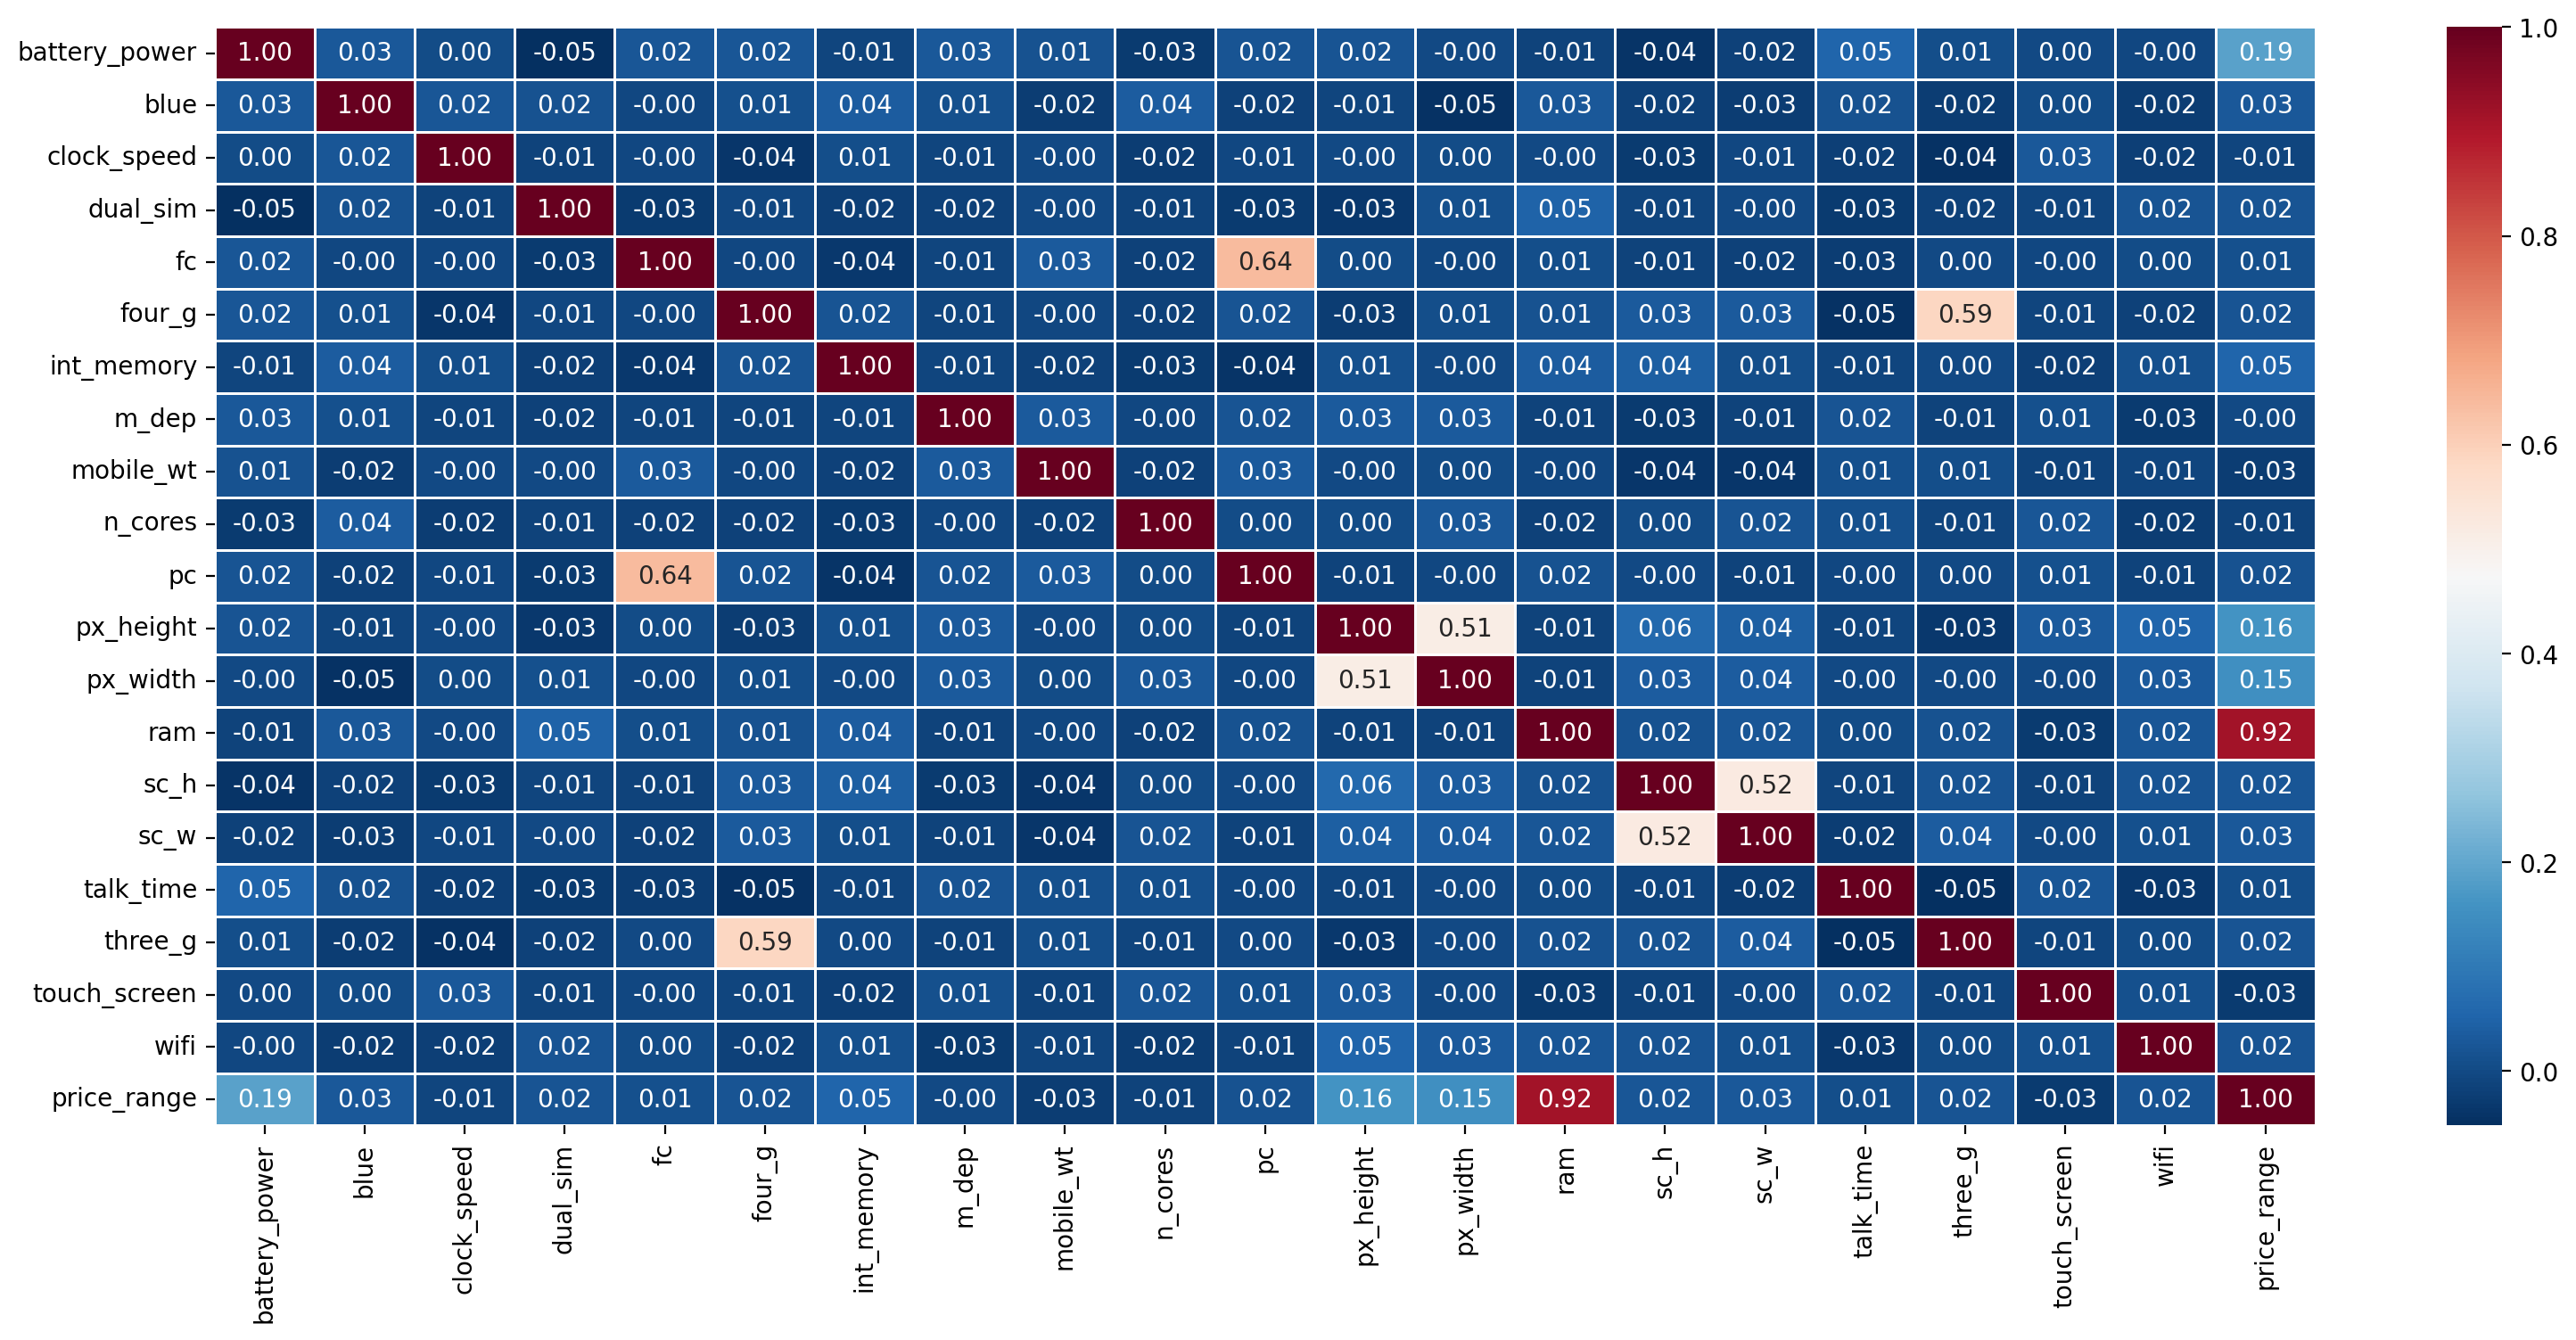

In [114]:
plt.figure(figsize=(19,8),dpi=200)
sns.heatmap(df.corr(),annot=True,fmt=".2f",linewidths=.5,cmap="RdBu_r")

<span style=font-size:16px>Based on this plot we can see that there is no specific shape or pattern for the decision boundaries in the data.However based on the visual apearance alone a linear kernel could be a reasonable choice.</span>

<Axes: xlabel='ram', ylabel='battery_power'>

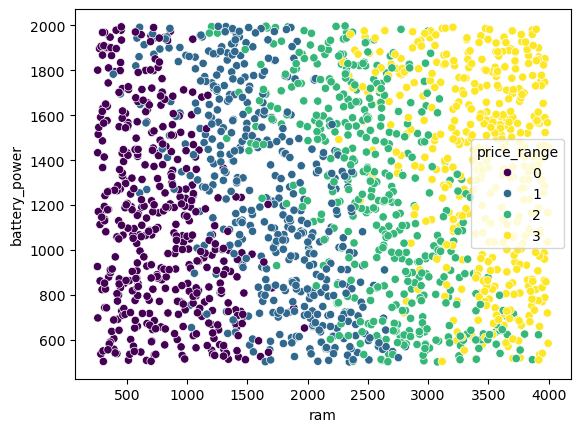

In [115]:
sns.scatterplot(data=df,x="ram",y="battery_power",hue="price_range",palette="viridis")

In [116]:
x=df.drop("price_range",axis=1)
y=df["price_range"].values.reshape(-1,1)
xscaled=scale(x)

In [117]:
x_train,x_test,y_train,y_test=train_test_split(xscaled,y.ravel(),test_size=0.1,random_state=0)
svm=SVC()
svm.fit(x_train,y_train)
y_pred=svm.predict(x_test)

In [118]:
print(f"test scores:{svm.score(x_test,y_test)}\ntraine scores:{svm.score(x_train,y_train)}")

test scores:0.9055555555555556
traine scores:0.983860955927995


In [119]:
print(metrics.classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.98      0.96      0.97        46
           1       0.86      0.84      0.85        45
           2       0.80      0.88      0.84        41
           3       0.98      0.94      0.96        48

    accuracy                           0.91       180
   macro avg       0.90      0.90      0.90       180
weighted avg       0.91      0.91      0.91       180



In [120]:
print(metrics.confusion_matrix(y_test,y_pred))

[[44  2  0  0]
 [ 1 38  6  0]
 [ 0  4 36  1]
 [ 0  0  3 45]]


In [121]:
params={"kernel":["linear","poly","rbf","sigmoid"],"C":[0.1,1,10,100],"gamma":["scale","auto"]}
gs=GridSearchCV(SVC(),params,cv=5,n_jobs=2)
gs.fit(x_train,y_train)
print(f"{gs.best_params_}\n{gs.best_score_}")

{'C': 10, 'gamma': 'scale', 'kernel': 'linear'}
0.9652423898621233


In [122]:
params=[{"kernel":["linear"],"C":[0.1,1,10,100],"gamma":["scale","auto"]},
        {"kernel":["poly"],"C":[0.1,1,10,100],"gamma":["scale","auto"],"degree":[0,2,3,4]},
        {"kernel":["rbf"],"C":[0.1,1,10,100],"gamma":["scale","auto"]},
        {"kernel":["sigmoid"],"C":[0.1,1,10,100],"gamma":["scale","auto"]}
       ]
gs=GridSearchCV(SVC(),params,cv=5,n_jobs=2)
gs.fit(x_train,y_train)
print(f"{gs.best_params_}\n{gs.best_score_}")

{'C': 10, 'gamma': 'scale', 'kernel': 'linear'}
0.9652423898621233


In [123]:
x=df.drop("price_range",axis=1)
y=df["price_range"].values.reshape(-1,1)
xscaled=scale(x)

In [124]:
x_train,x_test,y_train,y_test=train_test_split(xscaled,y.ravel(),test_size=0.1,random_state=0)
svm=SVC(kernel="linear",C=10,gamma="scale")
svm.fit(x_train,y_train)
y_pred=svm.predict(x_test)

<span style="font-size:16px"><b>Huge improvement</b> with Grid search lets see if there is more room for improvement.</span>

In [125]:
print(f"test scores:{svm.score(x_test,y_test)}\ntraine scores:{svm.score(x_train,y_train)}")

test scores:0.9777777777777777
traine scores:0.9832402234636871


In [126]:
print(metrics.classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.98      0.98      0.98        46
           1       0.96      0.98      0.97        45
           2       1.00      0.95      0.97        41
           3       0.98      1.00      0.99        48

    accuracy                           0.98       180
   macro avg       0.98      0.98      0.98       180
weighted avg       0.98      0.98      0.98       180



In [127]:
metrics.r2_score(y_test,y_pred)

0.9828322086840411

In [128]:
print(metrics.confusion_matrix(y_test,y_pred))

[[45  1  0  0]
 [ 1 44  0  0]
 [ 0  1 39  1]
 [ 0  0  0 48]]


In [129]:
x_svm=df.drop("price_range",axis=1)
y_svm=df["price_range"].values.reshape(-1,1)

In [130]:
svm_moded_df=df.copy()
svm_moded_test_df=test_df.copy()

In [131]:
feature_selection(0.9777777777777777,x_svm,y_svm,svm_moded_df,svm_moded_test_df,"price_range",0.15,
                  SVC(kernel="linear",C=10,gamma="scale"),scaler=True)

0.9777777777777777 
 Index(['battery_power', 'blue', 'clock_speed', 'dual_sim', 'fc', 'four_g',
       'int_memory', 'm_dep', 'mobile_wt', 'n_cores', 'pc', 'px_height',
       'px_width', 'ram', 'sc_h', 'sc_w', 'talk_time', 'three_g',
       'touch_screen', 'wifi'],
      dtype='object') 

0.9777777777777777 
 Index(['battery_power', 'blue', 'clock_speed', 'dual_sim', 'fc', 'four_g',
       'int_memory', 'm_dep', 'mobile_wt', 'n_cores', 'pc', 'px_height',
       'px_width', 'ram', 'sc_h', 'sc_w', 'talk_time', 'three_g',
       'touch_screen', 'wifi'],
      dtype='object') 

0.9777777777777777 
 Index(['battery_power', 'blue', 'clock_speed', 'dual_sim', 'fc', 'four_g',
       'int_memory', 'm_dep', 'mobile_wt', 'n_cores', 'pc', 'px_height',
       'px_width', 'ram', 'sc_h', 'sc_w', 'talk_time', 'three_g',
       'touch_screen', 'wifi'],
      dtype='object') 

0.9777777777777777 
 Index(['battery_power', 'blue', 'clock_speed', 'dual_sim', 'fc', 'four_g',
       'int_memory', 'm_dep', '

In [132]:
svm_moded_df

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,2,2.2,2,1,2,7,0.6,188,2,...,20,756,2549,9,7,19,2,2,3,1
1,1021,3,0.5,3,0,3,53,0.7,136,3,...,905,1988,2631,17,3,7,3,3,2,2
2,563,3,0.5,3,2,3,41,0.9,145,5,...,1263,1716,2603,11,2,9,3,3,2,2
3,615,3,2.5,2,0,2,10,0.8,131,6,...,1216,1786,2769,16,8,11,3,2,2,2
4,1821,3,1.2,2,13,3,44,0.6,141,2,...,1208,1212,1411,8,2,15,3,3,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1786,794,3,0.5,3,0,3,2,0.8,106,6,...,1222,1890,668,13,4,19,3,3,2,0
1787,1965,3,2.6,3,0,2,39,0.2,187,4,...,915,1965,2032,11,10,16,3,3,3,2
1788,1911,2,0.9,3,1,3,36,0.7,108,8,...,868,1632,3057,9,1,5,3,3,2,3
1789,1512,2,0.9,2,4,3,46,0.1,145,5,...,336,670,869,18,10,19,3,3,3,0


In [133]:
x=svm_moded_df.drop("price_range",axis=1)
y=svm_moded_df["price_range"].values.reshape(-1,1)
xscaled=scale(x)

In [134]:
x_train,x_test,y_train,y_test=train_test_split(xscaled,y.ravel(),test_size=0.15,random_state=0)
svm=SVC(kernel="linear",C=10,gamma="scale")
svm.fit(x_train,y_train)
y_pred=svm.predict(x_test)

<span style="font-size:16px">Feature selection improved our model further more we reached a great score now</span>

In [135]:
print(f"test scores:{svm.score(x_test,y_test)}\ntraine scores:{svm.score(x_train,y_train)}")

test scores:0.9739776951672863
traine scores:0.9835742444152431


In [136]:
svm_score=svm.score(x_test,y_test)
svm_f1=metrics.f1_score(y_test,y_pred,average="macro")

In [137]:
print(metrics.classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99        71
           1       0.97      0.95      0.96        64
           2       0.97      0.93      0.95        61
           3       0.97      1.00      0.99        73

    accuracy                           0.97       269
   macro avg       0.97      0.97      0.97       269
weighted avg       0.97      0.97      0.97       269



In [138]:
print(metrics.confusion_matrix(y_test,y_pred))

[[71  0  0  0]
 [ 1 61  2  0]
 [ 0  2 57  2]
 [ 0  0  0 73]]


In [139]:
svm_moded_test_df

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,pc,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi
0,1043,3,1.8,3,14,2,5,0.1,193,3,16,226,1412,3476,12,7,2,2,3,2
1,841,3,0.5,3,4,3,61,0.8,191,5,12,746,857,3895,6,0,7,3,2,2
2,1807,3,2.8,2,1,2,27,0.9,186,3,4,1270,1366,2396,17,10,10,2,3,3
3,1546,2,0.5,3,18,3,25,0.5,96,8,20,295,1752,3893,10,0,7,3,3,2
4,1434,2,1.4,2,11,3,49,0.5,108,6,18,749,810,1773,15,8,7,3,2,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,1700,3,1.9,2,0,3,54,0.5,170,7,17,644,913,2121,14,8,15,3,3,2
996,609,2,1.8,3,0,2,13,0.9,186,4,2,1152,1632,1933,8,1,19,2,3,3
997,1185,2,1.4,2,1,3,8,0.5,80,1,12,477,825,1223,5,0,14,3,2,2
998,1533,3,0.5,3,0,2,50,0.4,171,2,12,38,832,2509,15,11,6,2,3,2


In [140]:
svm_result=scale(svm_moded_test_df,is_user=True)

In [141]:
svm_result=svm.predict(svm_result)

In [142]:
svm_moded_test_df["price_range"]=svm_result

In [143]:
svm_moded_test_df["price_range"].value_counts()

price_range
2    263
3    256
0    253
1    228
Name: count, dtype: int64

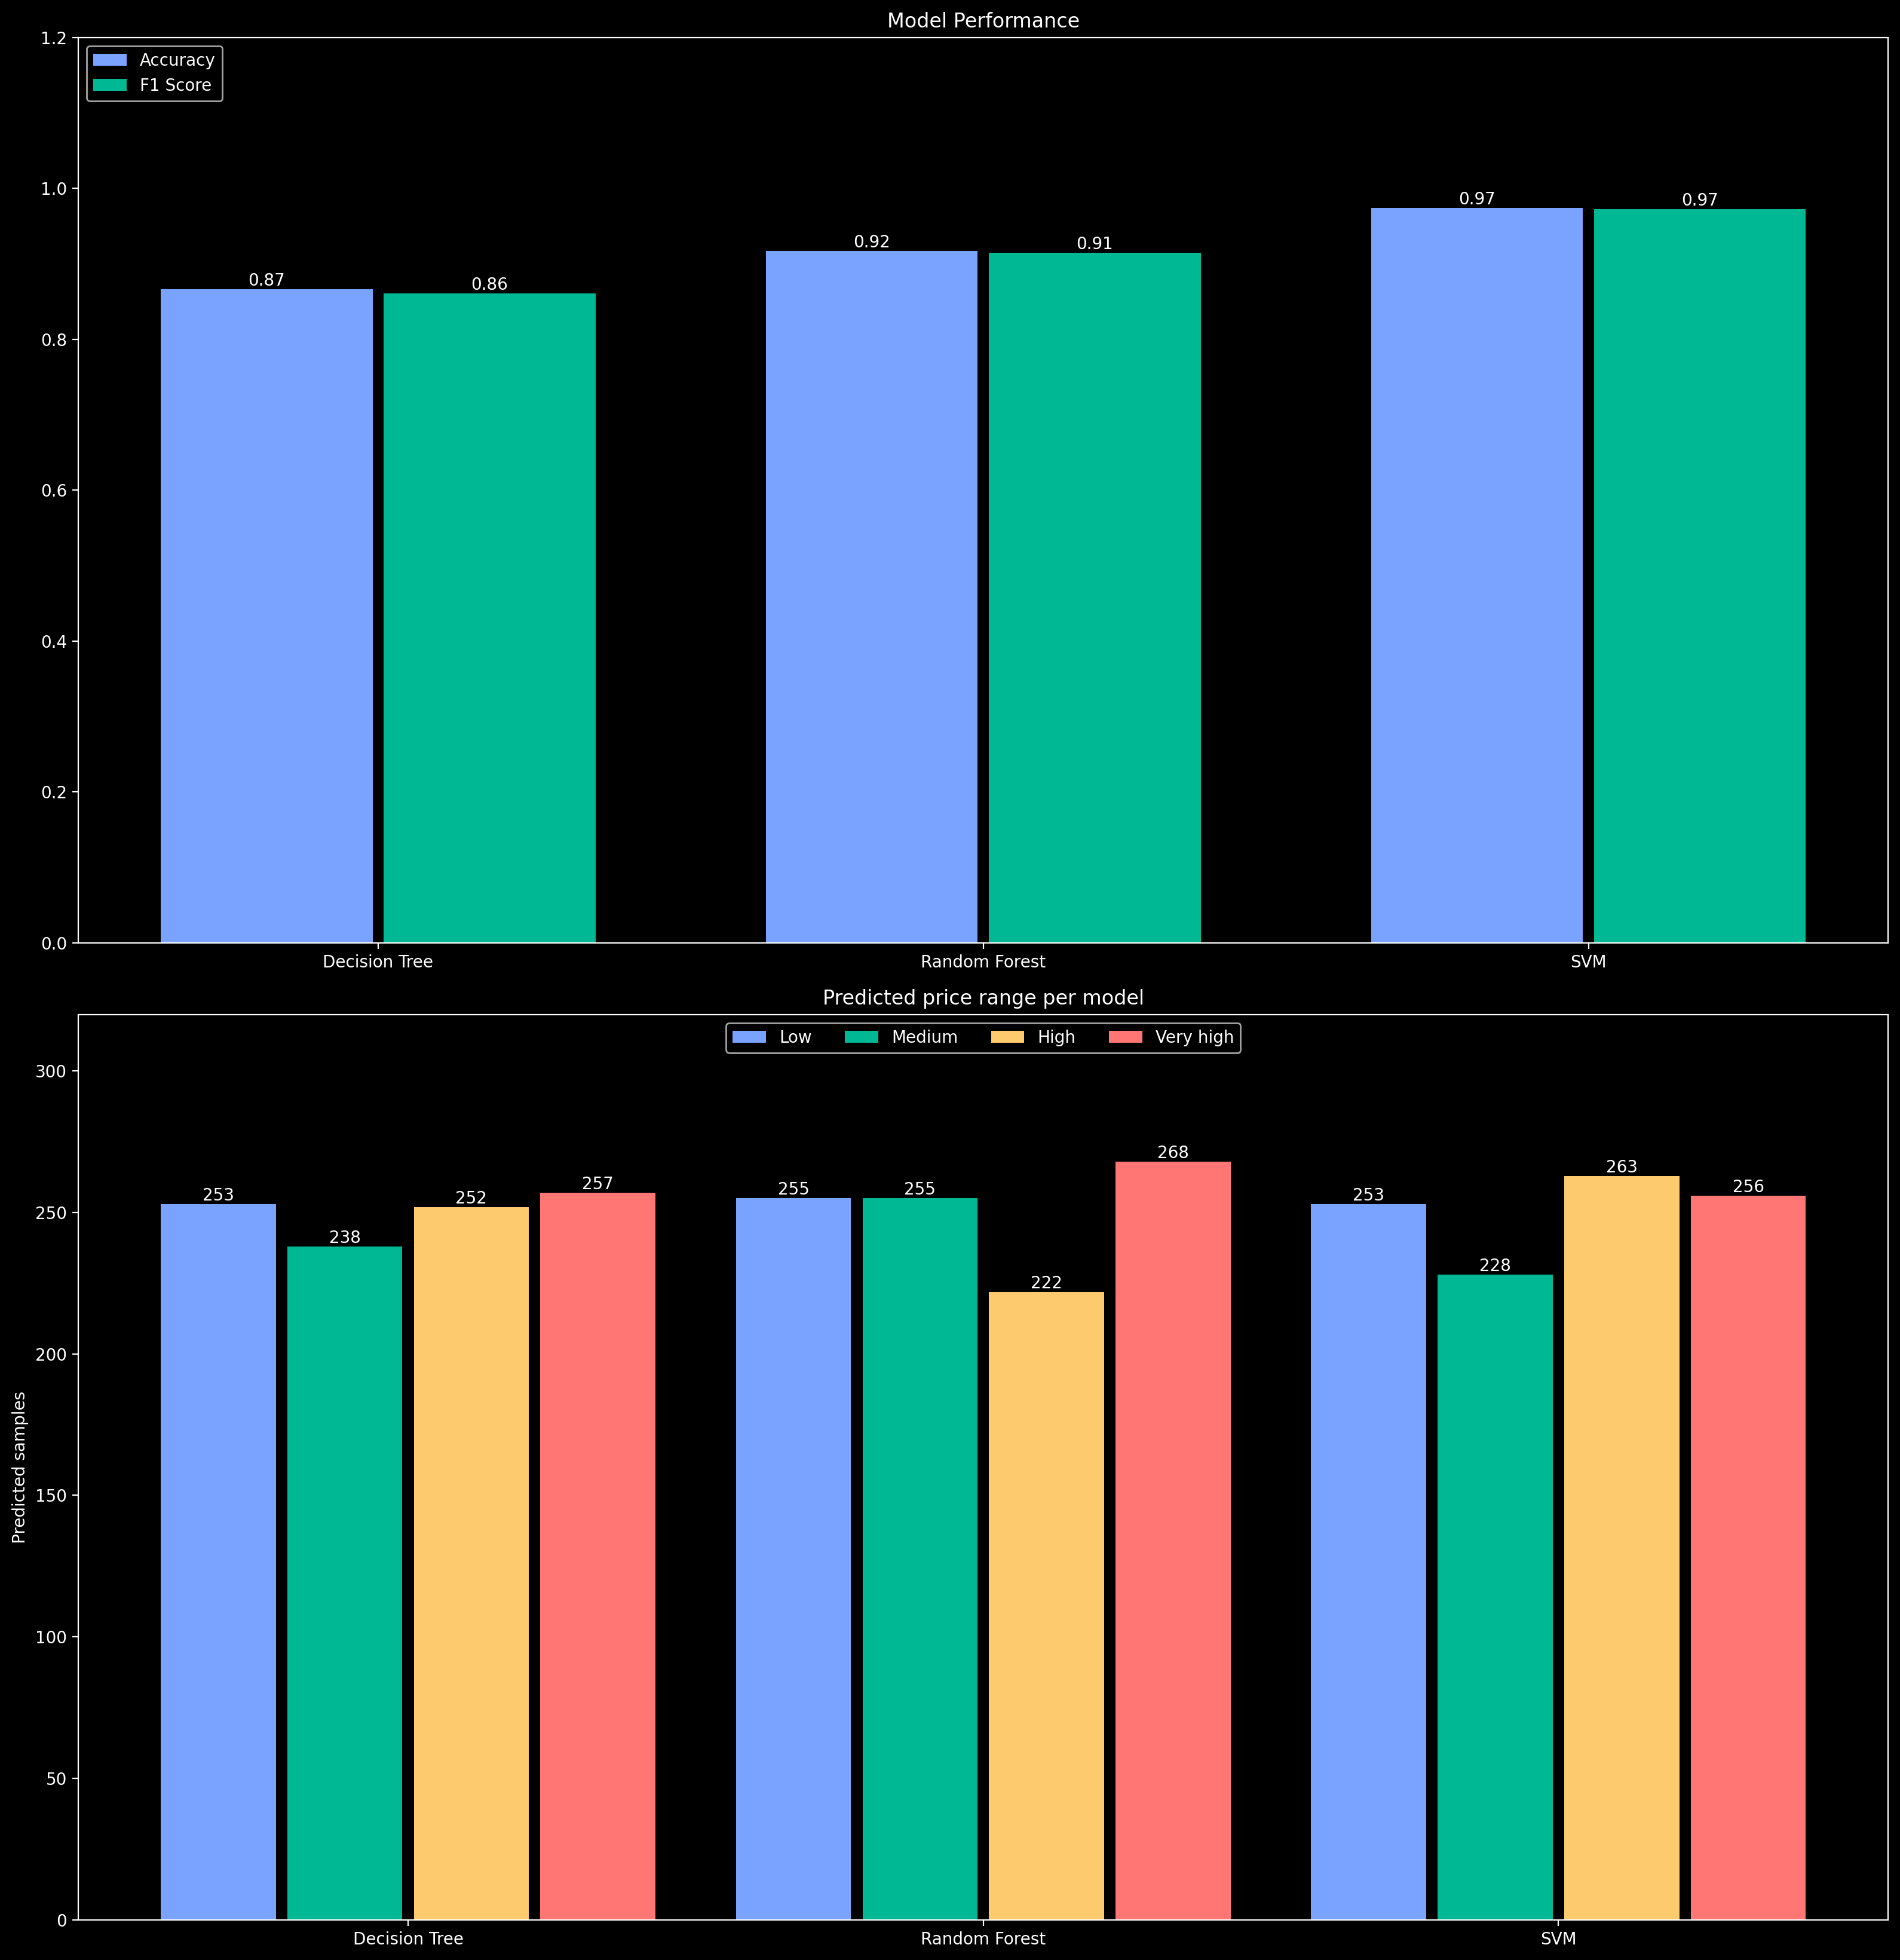

In [144]:
models=["Decision Tree","Random Forest","SVM"]
accuracy=[dts_score,rf_score,svm_score]
f1=[dts_f1,rf_f1,svm_f1]
counts={
    "Decision Tree":dts_result["price_range"].value_counts().sort_index(),
    "Random Forest":rf_ressult["price_range"].value_counts().sort_index(),
    "SVM":svm_moded_test_df["price_range"].value_counts().sort_index()}

class_names=["Low","Medium","High","Very high"]
colors=["#7aa2ff","#00b894","#fdcb6e","#ff7675"]
x=np.arange(len(models))   

plt.style.use("dark_background")
fig,(ax1,ax2)=plt.subplots(2,1,figsize=(16, 16.5),dpi=200)
#w is the width of bars and x is their location
w = 0.35
b1 = ax1.bar(x - w/1.9, accuracy, w, label="Accuracy", color="#7aa2ff")
#x-w/1.9 = the location of accuracy bar(x=0,1,2(its the center location of every bar))so the location of first bar is less tha location number 0
b2 = ax1.bar(x + w/1.9, f1, w, label="F1 Score", color="#00b894")
ax1.bar_label(b1, fmt="%.2f")
ax1.bar_label(b2, fmt="%.2f")
ax1.set_xticks(x)
ax1.set_xticklabels(models)
ax1.set_ylim(0, 1.2)
ax1.set_title("Model Performance")
ax1.legend(loc="upper left")

for k in range(4):
    vals = [counts[m][k] for m in models]
    bars = ax2.bar(x + (k - 1.5) * 0.22, vals, 0.2, label=class_names[k], color=colors[k])
    ax2.bar_label(bars)
ax2.set_xticks(x)
ax2.set_xticklabels(models)
ax2.set_ylim(0, 320)
ax2.set_ylabel("Predicted samples")
ax2.set_title("Predicted price range per model")
ax2.legend(ncol=4, loc="upper center")

plt.tight_layout()
plt.show()

<span style="font-size:16px">Best performance is for SVM model with 97 for both f1 score and accuracy.there for i can say it will work better on unseen data far much better than Decision Tree and Random Forest.</span>